# Notebook 01 — Análisis Estadístico del Dataset CIC-IoT-2023

**Proyecto:** Módulo de Detección para IDS Pasivo  
**Autor:** Alvarez, Julián Manuel  
**Hito:** 1 — Análisis exhaustivo de la estructura, distribución de clases,
desbalance y relevancia de los atributos del dataset CIC-IoT-2023.

---

## Objetivo

Este notebook constituye el punto de entrada del pipeline de desarrollo.
Su propósito es exclusivamente **analítico y exploratorio**: no entrena
ningún modelo ni exporta artefactos. Los hallazgos aquí documentados
informan directamente las decisiones de diseño del Hito 2
(selección de características).

## Estructura

1. Configuración del entorno
2. Carga del dataset
3. Estructura general
4. Distribución de clases y desbalance
5. Estadísticas descriptivas por feature
6. Detección de valores problemáticos (NaN, infinitos, outliers)
7. Análisis de correlación entre features
8. Distribución de features clave por clase
10. Conclusiones y notas para Hito 2

---

> **Nota de hardware:** Este notebook fue diseñado para ejecutarse en la
> máquina local (Windows, CPU-only). La estrategia de carga usa un límite
> de filas por archivo (`MAX_ROWS_PER_FILE`) para controlar el uso de RAM.
> En el servidor HPC se puede establecer ese parámetro en `None` para
> cargar el dataset completo (~22 M de filas).

## 1. Configuración del entorno

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Importaciones
# ─────────────────────────────────────────────────────────────────────────────
from __future__ import annotations

import os
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Semilla de reproducibilidad
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)

# ─────────────────────────────────────────────────────────────────────────────
# Estilo de visualizaciones
# ─────────────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

# ─────────────────────────────────────────────────────────────────────────────
# Opciones de visualización de Pandas
# ─────────────────────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 40)

print("✓ Entorno configurado.")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")

✓ Entorno configurado.
  numpy  1.26.4
  pandas 3.0.2


## 2. Carga del dataset

El dataset CIC-IoT-2023 está distribuido en **169 archivos CSV** dentro
del directorio `wataiData/csv/CICIoT2023/`. La descarga se realiza
automáticamente mediante `kagglehub`, que gestiona un caché local: si el
dataset ya fue descargado previamente, **no se vuelve a bajar**.

**Prerequisito:** el archivo `kaggle.json` debe estar ubicado en
`C:\Users\<usuario>\.kaggle\kaggle.json` (ver README para instrucciones).

Para controlar el uso de RAM en la máquina local se define
`MAX_ROWS_PER_FILE`. En el servidor HPC se puede establecer en `None`
para cargar el dataset completo.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Parámetros de carga — ajustar según el entorno
# ─────────────────────────────────────────────────────────────────────────────

# Identificador del dataset en Kaggle
KAGGLE_DATASET_ID: str = "madhavmalhotra/unb-cic-iot-dataset"

# Subdirectorio relativo donde se encuentran los CSVs dentro del dataset
CSV_SUBDIR: str = os.path.join("wataiData", "csv", "CICIoT2023")

# Nombre de la columna de etiquetas en el dataset
LABEL_COL: str = "label"

# Límite de filas a leer por archivo CSV.
# Valor recomendado en PC local (Windows, CPU-only): 15_000
# En servidor HPC sin restricciones de RAM:          None
MAX_ROWS_PER_FILE: Optional[int] = None


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Descarga del dataset con KaggleHub
#
# kagglehub.dataset_download() es cache-aware: si el dataset ya existe
# en el caché local (~/.cache/kagglehub), retorna la ruta directamente
# sin volver a descargar. La primera ejecución puede tardar varios minutos
# dependiendo de la conexión (~1.5 GB).
# ─────────────────────────────────────────────────────────────────────────────
import kagglehub

print("⬇️  Localizando dataset (descarga o caché)...")
download_path: str = kagglehub.dataset_download(KAGGLE_DATASET_ID)
print(f"✓ Dataset disponible en: {download_path}")

CSV_DIR: Path = Path(download_path) / CSV_SUBDIR

if not CSV_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró el directorio de CSVs en: {CSV_DIR}\n"
        f"Verificar que CSV_SUBDIR = '{CSV_SUBDIR}' sea correcto."
    )

csv_files: list[Path] = sorted(CSV_DIR.glob("*.csv"))

print(f"\n✓ Archivos CSV encontrados: {len(csv_files)}")
print("  Primeros 5 archivos:")
for f in csv_files[:5]:
    print(f"    {f.name}")

⬇️  Localizando dataset (descarga o caché)...
✓ Dataset disponible en: C:\Users\herna\.cache\kagglehub\datasets\madhavmalhotra\unb-cic-iot-dataset\versions\1

✓ Archivos CSV encontrados: 169
  Primeros 5 archivos:
    part-00000-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
    part-00001-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
    part-00002-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
    part-00003-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
    part-00004-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Carga incremental por batches con persistencia en disco
#
# Estrategia para controlar el uso de RAM con 169 archivos CSV:
#
#   1. Procesar los CSVs de a BATCH_SIZE archivos.
#   2. Concatenar el batch en RAM, normalizar columnas y limpiar valores.
#   3. Escribir el batch al archivo Feather de salida:
#        - Primer batch  → crear el archivo (write).
#        - Batches resto → leer el acumulado, concatenar y reescribir (append).
#   4. Liberar RAM con gc.collect() antes del siguiente batch.
#   5. Al finalizar, leer el Feather completo una sola vez para el análisis.
#   6. Al terminar el notebook, eliminar el archivo Feather del disco.
#
# El archivo Feather es solo un buffer temporal de este notebook.
# No es un artefacto del proyecto — se elimina al final de la sesión.
# ─────────────────────────────────────────────────────────────────────────────

import gc
import pyarrow.feather as feather

# ── Parámetros del batch ─────────────────────────────────────────────────────

# Cantidad de archivos CSV a procesar por iteración.
# Aumentar si la RAM disponible lo permite (ej. 10 en HPC).
BATCH_SIZE: int = 10

# Ruta del archivo Feather temporal en disco
FEATHER_TEMP_PATH: Path = Path("dataset_eda_temp.feather")


# ── Funciones auxiliares ─────────────────────────────────────────────────────

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normaliza los nombres de columna del DataFrame.

    Transforma a minúsculas, elimina espacios laterales y reemplaza
    espacios y caracteres especiales por guión bajo. Garantiza que
    todos los archivos del dataset compartan el mismo esquema de nombres
    antes de ser concatenados.

    Args:
        df: DataFrame con columnas a normalizar.

    Returns:
        El mismo DataFrame con los nombres de columna normalizados.
    """
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(r"[^\w]", "_", regex=True)
    )
    return df


def load_batch(paths: list[Path], nrows: Optional[int]) -> tuple[pd.DataFrame, list[str]]:
    """
    Carga y concatena un batch de archivos CSV en un único DataFrame.

    Los archivos vacíos o corruptos se omiten y se registran en la
    lista de skipped para su reporte al final del proceso.

    Args:
        paths:  Lista de rutas a los archivos CSV del batch.
        nrows:  Límite de filas por archivo (None para sin límite).

    Returns:
        Tupla (DataFrame concatenado del batch, lista de archivos omitidos).
    """
    frames: list[pd.DataFrame] = []
    skipped_in_batch: list[str] = []

    for path in paths:
        try:
            chunk = pd.read_csv(path, nrows=nrows, low_memory=False)

            if chunk.empty:
                skipped_in_batch.append(path.name)
                continue

            chunk = normalize_columns(chunk)
            frames.append(chunk)

        except Exception as exc:
            skipped_in_batch.append(path.name)
            tqdm.write(f"  ⚠️  Error en {path.name}: {exc}")

    if not frames:
        return pd.DataFrame(), skipped_in_batch

    return pd.concat(frames, ignore_index=True), skipped_in_batch


def append_to_feather(batch_df: pd.DataFrame, feather_path: Path) -> None:
    """
    Escribe un batch en el archivo Feather acumulativo.

    Si el archivo ya existe, lo lee, concatena el nuevo batch y reescribe.
    Si no existe, lo crea directamente con el batch actual.

    Feather es preferido sobre CSV para este buffer porque:
      - Es un formato binario columnar: lectura/escritura ~10x más rápida.
      - Preserva los tipos de dato sin reinfencia al recargar.
      - No requiere parsing de texto en cada iteración.

    Args:
        batch_df:     DataFrame del batch actual a agregar.
        feather_path: Ruta al archivo Feather de persistencia.
    """
    if feather_path.exists():
        # Leer el acumulado existente, concatenar y reescribir
        existing = feather.read_feather(feather_path)
        combined = pd.concat([existing, batch_df], ignore_index=True)
        del existing  # Liberar el DataFrame leído antes de reescribir
    else:
        combined = batch_df

    feather.write_feather(combined, feather_path)
    del combined


# ── Bucle principal de carga por batches ─────────────────────────────────────

# Eliminar archivo temporal previo si existe (ejecución limpia)
if FEATHER_TEMP_PATH.exists():
    FEATHER_TEMP_PATH.unlink()
    print(f"🗑  Archivo temporal previo eliminado: {FEATHER_TEMP_PATH}")

skipped_all: list[str] = []
n_batches: int = (len(csv_files) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"Iniciando carga — {len(csv_files)} archivos en {n_batches} batches de {BATCH_SIZE}...\n")

for batch_idx in tqdm(range(n_batches), desc="Batches procesados"):

    # Seleccionar el slice de archivos correspondiente al batch
    batch_paths = csv_files[batch_idx * BATCH_SIZE : (batch_idx + 1) * BATCH_SIZE]

    # 1. Cargar y concatenar el batch en RAM
    batch_df, skipped_batch = load_batch(batch_paths, MAX_ROWS_PER_FILE)
    skipped_all.extend(skipped_batch)

    if batch_df.empty:
        continue

    # 2. Persistir el batch en el archivo Feather acumulativo
    append_to_feather(batch_df, FEATHER_TEMP_PATH)

    # 3. Liberar RAM: eliminar el batch de memoria y forzar al GC
    del batch_df
    gc.collect()

# ── Reporte de archivos omitidos ─────────────────────────────────────────────

if skipped_all:
    print(f"\n⚠️  Archivos omitidos en total ({len(skipped_all)}): {skipped_all}")

# ── Lectura final del Feather completo para el análisis ──────────────────────

print("\nCargando dataset completo desde disco para el análisis...")
df: pd.DataFrame = feather.read_feather(FEATHER_TEMP_PATH)

print(f"\n✓ Dataset consolidado.")
print(f"  Filas totales  : {df.shape[0]:,}")
print(f"  Columnas       : {df.shape[1]}")
print(f"  Memoria en RAM : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"  Archivo en disco: {FEATHER_TEMP_PATH} "
      f"({FEATHER_TEMP_PATH.stat().st_size / 1024**2:.1f} MB)")
print(f"\n  ⚠️  Recordatorio: ejecutar la celda de limpieza al final del notebook.")

Iniciando carga — 169 archivos en 17 batches de 10...



Batches procesados:   0%|          | 0/17 [00:00<?, ?it/s]


Cargando dataset completo desde disco para el análisis...

✓ Dataset consolidado.
  Filas totales  : 46,686,579
  Columnas       : 47
  Memoria en RAM : 17427.8 MB
  Archivo en disco: dataset_eda_temp.feather (3816.0 MB)

  ⚠️  Recordatorio: ejecutar la celda de limpieza al final del notebook.


## 3. Estructura general del dataset

In [4]:
import gc
import pyarrow.feather as feather

# ── Parámetros del batch ─────────────────────────────────────────────────────

# Cantidad de archivos CSV a procesar por iteración.
# Aumentar si la RAM disponible lo permite (ej. 10 en HPC).
BATCH_SIZE: int = 10

# Ruta del archivo Feather temporal en disco
FEATHER_TEMP_PATH: Path = Path("dataset_eda_temp.feather")
print("\nCargando dataset completo desde disco para el análisis...")
df: pd.DataFrame = feather.read_feather(FEATHER_TEMP_PATH)
# ─────────────────────────────────────────────────────────────────────────────
# Tipos de datos y uso de memoria por columna
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)
df.info(memory_usage="deep")


Cargando dataset completo desde disco para el análisis...
INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 46686579 entries, 0 to 46686578
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   header_length    float64
 2   protocol_type    float64
 3   duration         float64
 4   rate             float64
 5   srate            float64
 6   drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  http             float64
 20  https            float64
 21  dns              float64
 22  telnet           float64
 23  smtp             float64
 24  ssh              float64
 25  ir

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Primeras filas — verificación visual de estructura
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nPrimeras 5 filas del dataset consolidado:")
df.head()


Primeras 5 filas del dataset consolidado:


,flow_duration,header_length,protocol_type,duration,rate,srate,drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,http,https,dns,telnet,smtp,ssh,irc,tcp,udp,dhcp,arp,icmp,ipv,llc,tot_sum,min,max,avg,std,tot_size,iat,number,magnitue,radius,covariance,variance,weight,label
0,0.0000,54.0000,6.0000,64.0000,0.3298,0.3298,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,83343831.9201,9.5000,10.3923,0.0000,0.0000,0.0000,141.5500,DDoS-RSTFINFlood
1,0.0000,57.0400,6.3300,64.0000,4.2906,4.2906,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,581.3300,54.0000,66.3000,54.7964,2.8230,57.0400,82926067.4667,9.5000,10.4647,4.0104,160.9878,0.0500,141.5500,DoS-TCP_Flood
2,0.0000,0.0000,1.0000,64.0000,33.3968,33.3968,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,441.0000,42.0000,42.0000,42.0000,0.0000,42.0000,83127993.9277,9.5000,9.1652,0.0000,0.0000,0.0000,141.5500,DDoS-ICMP_Flood
3,0.3282,76175.0000,17.0000,64.0000,4642.1330,4642.1330,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,525.0000,50.0000,50.0000,50.0000,0.0000,50.0000,83015696.3810,9.5000,10.0000,0.0000,0.0000,0.0000,141.5500,DoS-UDP_Flood
4,0.1173,101.7300,6.1100,65.9100,6.2022,6.2022,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0100,0.0400,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,644.6000,57.8800,131.6000,67.9592,23.1131,57.8800,82972999.1825,9.5000,11.3469,32.7162,3016.8083,0.1900,141.5500,DoS-SYN_Flood


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Separación de columnas por tipo de dato
#
# Relevante para decidir qué features requieren codificación y cuáles
# pueden ingresar directamente al modelo como valores numéricos.
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols: list[str] = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols:  list[str] = df.select_dtypes(include=["object"]).columns.tolist()

# Excluir la columna de etiquetas de las numéricas si aplica
feature_cols: list[str] = [c for c in numeric_cols if c != LABEL_COL]

print(f"Columnas numéricas (features) : {len(feature_cols)}")
print(f"Columnas de tipo object       : {len(object_cols)}")
if object_cols:
    print(f"  → {object_cols}")

Columnas numéricas (features) : 46
Columnas de tipo object       : 1
  → ['label']


## 4. Distribución de clases y desbalance

El desbalance de clases es uno de los principales desafíos del dataset
CIC-IoT-2023. Su cuantificación aquí determina la estrategia de
muestreo (SMOTE, undersampling, pesos de clase) a aplicar en el Hito 3.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla de distribución de clases
#
# value_counts() se llama UNA sola vez sobre la columna de etiquetas.
# El porcentaje se deriva dividiendo por el total — sin segunda pasada
# sobre el DataFrame, sin copias adicionales en memoria.
# ─────────────────────────────────────────────────────────────────────────────
class_counts: pd.Series = df[LABEL_COL].value_counts()

# Derivar porcentaje desde los conteos ya calculados — sin releer df
class_pct: pd.Series = class_counts / class_counts.sum() * 100

class_summary: pd.DataFrame = pd.DataFrame({
    "count": class_counts,
    "percent": class_pct.round(4)
})
class_summary.index.name = "class"

print(f"Clases únicas en el dataset: {len(class_counts)}\n")
print(class_summary.to_string())


Clases únicas en el dataset: 34

                           count  percent
class                                    
DDoS-ICMP_Flood          7200504  15.4231
DDoS-UDP_Flood           5412287  11.5928
DDoS-TCP_Flood           4497667   9.6337
DDoS-PSHACK_Flood        4094755   8.7707
DDoS-SYN_Flood           4059190   8.6946
DDoS-RSTFINFlood         4045285   8.6648
DDoS-SynonymousIP_Flood  3598138   7.7070
DoS-UDP_Flood            3318595   7.1082
DoS-TCP_Flood            2671445   5.7221
DoS-SYN_Flood            2028834   4.3456
BenignTraffic            1098195   2.3523
Mirai-greeth_flood        991866   2.1245
Mirai-udpplain            890576   1.9076
Mirai-greip_flood         751682   1.6101
DDoS-ICMP_Fragmentation   452489   0.9692
MITM-ArpSpoofing          307593   0.6588
DDoS-UDP_Fragmentation    286925   0.6146
DDoS-ACK_Fragmentation    285104   0.6107
DNS_Spoofing              178911   0.3832
Recon-HostDiscovery       134378   0.2878
Recon-OSScan               98259   0.2105
R

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Métricas de desbalance
#
# Imbalance Ratio (IR): cociente entre la clase mayoritaria y la minoritaria.
# Un IR alto indica desbalance severo y anticipa la necesidad de técnicas
# de rebalanceo para evitar sesgo del modelo hacia la clase dominante.
# ─────────────────────────────────────────────────────────────────────────────
majority_class: str   = class_counts.idxmax()
minority_class: str   = class_counts.idxmin()
imbalance_ratio: float = class_counts.max() / class_counts.min()

print(f"Clase mayoritaria : {majority_class!r:<40} ({class_counts.max():,} muestras)")
print(f"Clase minoritaria : {minority_class!r:<40} ({class_counts.min():,} muestras)")
print(f"Imbalance Ratio   : {imbalance_ratio:.1f}x")

if imbalance_ratio > 100:
    print("\n⚠️  Desbalance severo (IR > 100). Se requerirá SMOTE o clase ponderada.")
elif imbalance_ratio > 10:
    print("\n⚠️  Desbalance moderado (IR > 10). Se evaluará rebalanceo.")
else:
    print("\n✓ Desbalance leve (IR ≤ 10).")

Clase mayoritaria : 'DDoS-ICMP_Flood'                        (7,200,504 muestras)
Clase minoritaria : 'Uploading_Attack'                       (1,252 muestras)
Imbalance Ratio   : 5751.2x

⚠️  Desbalance severo (IR > 100). Se requerirá SMOTE o clase ponderada.


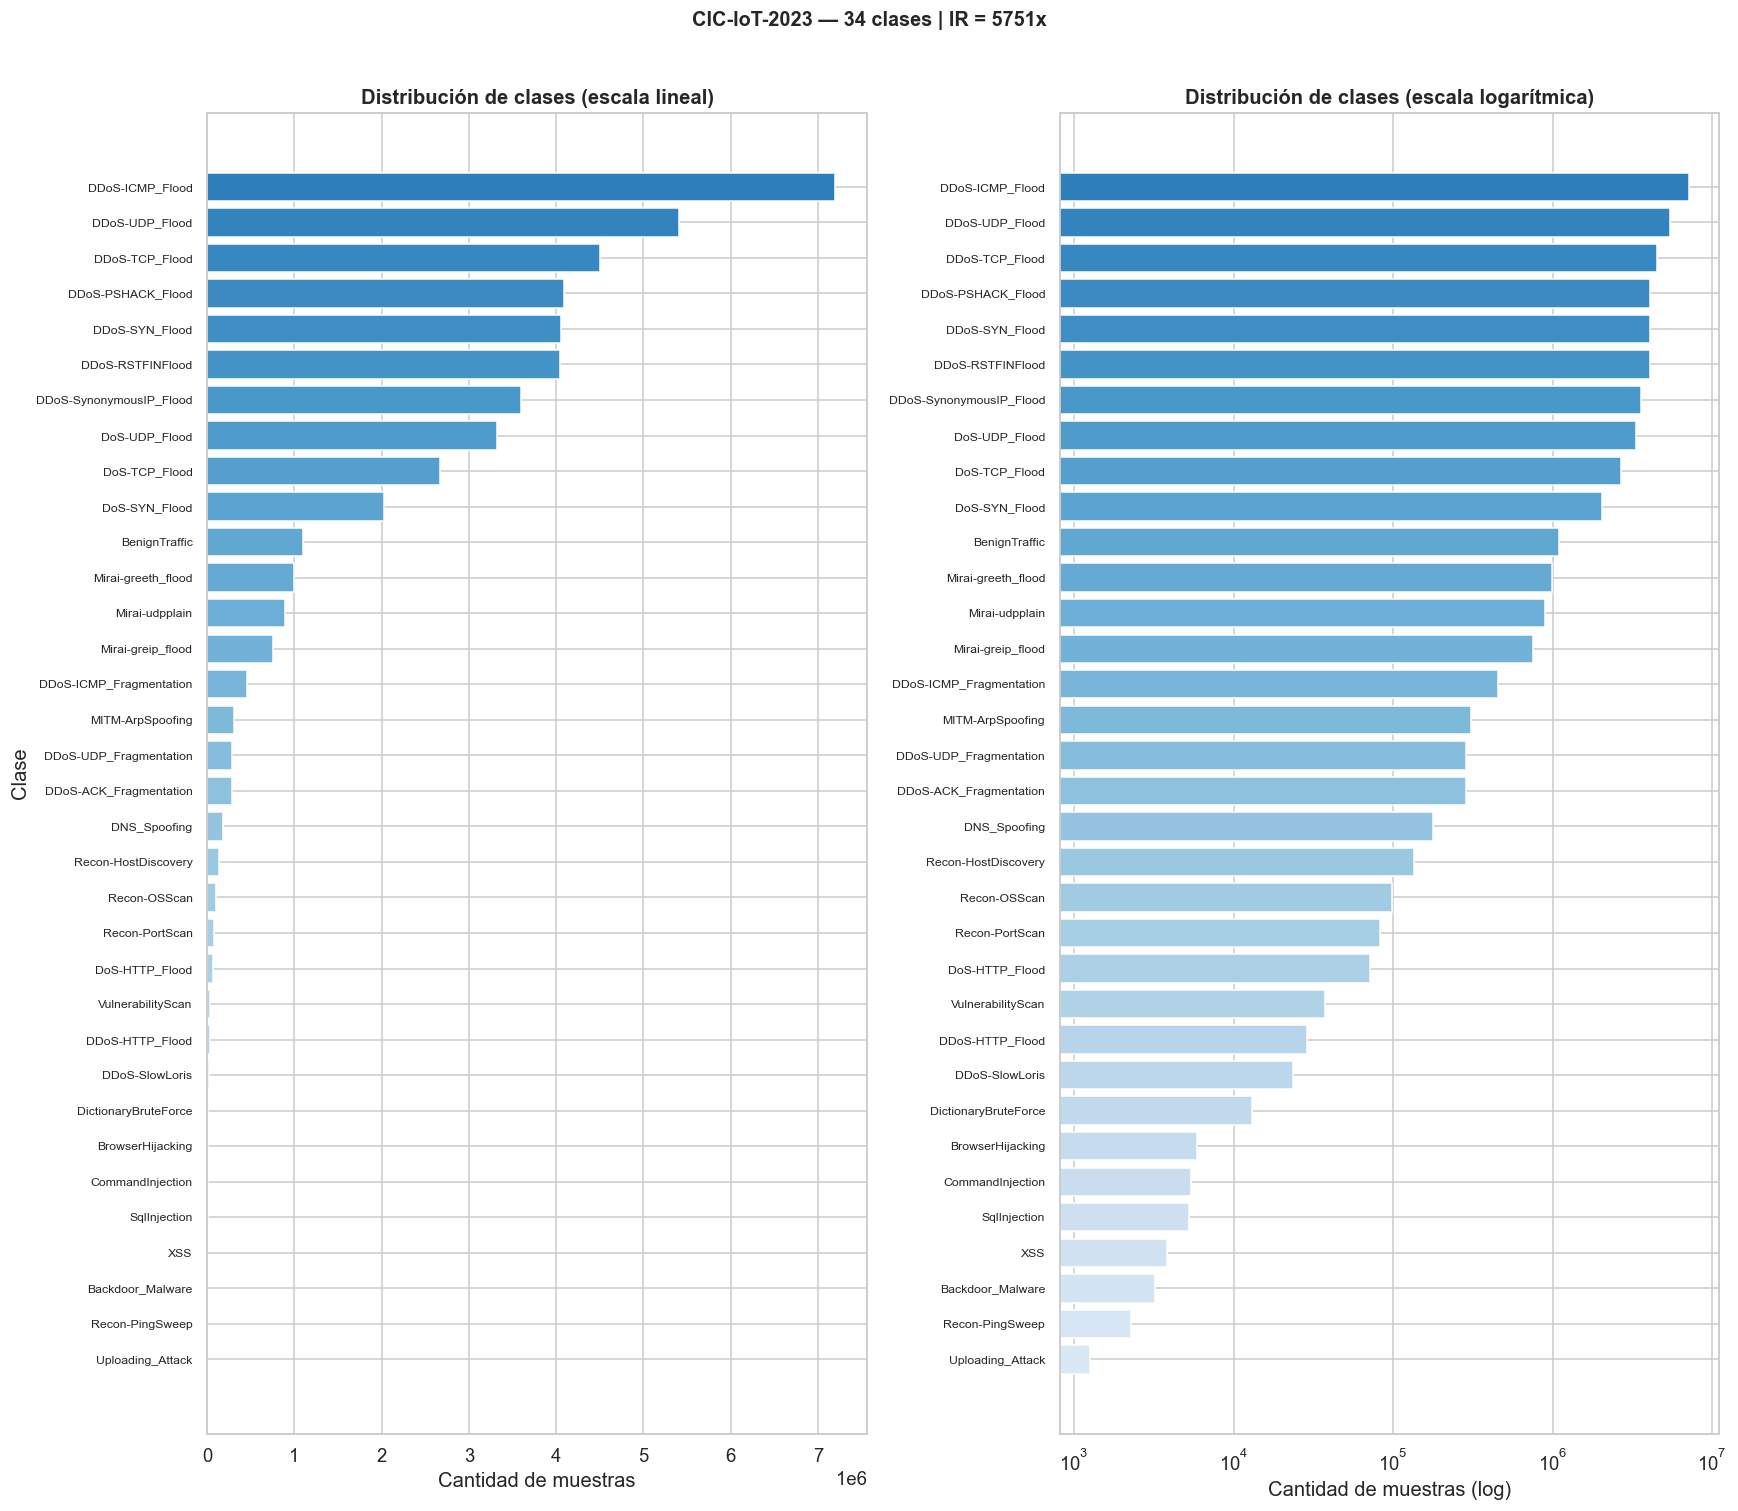

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización: distribución de clases (escala lineal y logarítmica)
#
# IMPORTANTE: se usa ax.barh() de Matplotlib en lugar de sns.barplot().
# Seaborn ≥0.12 ejecuta bootstrapping estadístico internamente para calcular
# intervalos de confianza, lo que genera copias masivas del input en memoria
# y mata el kernel con datasets de 45M+ filas.
#
# ax.barh() dibuja directamente desde los arrays de conteos (34 valores),
# sin ningún cálculo estadístico intermedio. Uso de RAM: despreciable.
# ─────────────────────────────────────────────────────────────────────────────

# Los conteos ya están calculados como Series de 34 elementos (una por clase).
# Nunca se pasa el DataFrame completo a la función de graficado.
counts_values = class_counts.values          # array de 34 enteros
counts_labels = class_counts.index.tolist()  # lista de 34 strings
n_classes     = len(counts_labels)

# Paleta de azules degradada (de más oscuro a más claro, por orden descendente)
palette = plt.cm.Blues_r(np.linspace(0.3, 0.85, n_classes))

row_height = 0.4  # altura de cada barra en pulgadas
fig_h      = max(6, n_classes * row_height)
fig, axes  = plt.subplots(1, 2, figsize=(16, fig_h))

# — Gráfico izquierdo: escala lineal —
axes[0].barh(counts_labels, counts_values, color=palette)
axes[0].invert_yaxis()  # clase más frecuente arriba
axes[0].set_title("Distribución de clases (escala lineal)", fontweight="bold")
axes[0].set_xlabel("Cantidad de muestras")
axes[0].set_ylabel("Clase")
axes[0].tick_params(axis="y", labelsize=8)

# — Gráfico derecho: escala logarítmica —
axes[1].barh(counts_labels, counts_values, color=palette)
axes[1].invert_yaxis()
axes[1].set_xscale("log")
axes[1].set_title("Distribución de clases (escala logarítmica)", fontweight="bold")
axes[1].set_xlabel("Cantidad de muestras (log)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=8)

plt.suptitle(
    f"CIC-IoT-2023 — {n_classes} clases | IR = {imbalance_ratio:.0f}x",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

## 5. Estadísticas descriptivas por feature

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Estadísticas descriptivas completas de las features numéricas
#
# Se incluye el coeficiente de variación (CV = std / mean) como indicador
# de dispersión relativa. Features con CV muy alto suelen ser candidatas
# para normalización robusta o remoción por alta varianza de ruido.
# ─────────────────────────────────────────────────────────────────────────────
desc: pd.DataFrame = df[feature_cols].describe().T

# Agregar coeficiente de variación y cantidad de ceros
desc["cv"]       = desc["std"] / desc["mean"].replace(0, np.nan)
desc["zero_pct"] = (df[feature_cols] == 0).sum() / len(df) * 100

desc = desc[["count", "mean", "std", "cv", "min", "25%", "50%", "75%", "max", "zero_pct"]]
desc.index.name = "feature"

print("Estadísticas descriptivas (features numéricas):")
desc.sort_values("zero_pct", ascending=False)

Estadísticas descriptivas (features numéricas):


,count,mean,std,cv,min,25%,50%,75%,max,zero_pct
feature,,,,,,,,,,
telnet,46686579.0000,0.0000,0.0001,6832.7578,0.0000,0.0000,0.0000,0.0000,1.0000,100.0000
smtp,46686579.0000,0.0000,0.0003,3944.8945,0.0000,0.0000,0.0000,0.0000,1.0000,100.0000
irc,46686579.0000,0.0000,0.0004,2582.5395,0.0000,0.0000,0.0000,0.0000,1.0000,100.0000
cwr_flag_number,46686579.0000,0.0000,0.0009,1171.8079,0.0000,0.0000,0.0000,0.0000,1.0000,99.9999
ece_flag_number,46686579.0000,0.0000,0.0012,822.5668,0.0000,0.0000,0.0000,0.0000,1.0000,99.9999
dhcp,46686579.0000,0.0000,0.0013,763.9249,0.0000,0.0000,0.0000,0.0000,1.0000,99.9998
ssh,46686579.0000,0.0000,0.0064,156.2992,0.0000,0.0000,0.0000,0.0000,1.0000,99.9959
drate,46686579.0000,0.0000,0.0073,1327.0193,0.0000,0.0000,0.0000,0.0000,29.7152,99.9937
arp,46686579.0000,0.0001,0.0081,122.9143,0.0000,0.0000,0.0000,0.0000,1.0000,99.9934


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Features con alta proporción de ceros
#
# Una feature con >85% de ceros aporta escasa información discriminativa
# y puede ser candidata a eliminación en el Hito 2.
# ─────────────────────────────────────────────────────────────────────────────
HIGH_ZERO_THRESHOLD: float = 85.0

high_zero_features: pd.DataFrame = (
    desc[desc["zero_pct"] > HIGH_ZERO_THRESHOLD][["zero_pct"]]
    .sort_values("zero_pct", ascending=False)
)

if high_zero_features.empty:
    print(f"✓ Ninguna feature supera el {HIGH_ZERO_THRESHOLD}% de valores cero.")
else:
    print(
        f"⚠️  Features con >{HIGH_ZERO_THRESHOLD}% de ceros "
        f"({len(high_zero_features)} features):"
    )
    print(high_zero_features.to_string())

⚠️  Features con >85.0% de ceros (18 features):
                 zero_pct
feature                  
telnet           100.0000
smtp             100.0000
irc              100.0000
cwr_flag_number   99.9999
ece_flag_number   99.9999
dhcp              99.9998
ssh               99.9959
drate             99.9937
arp               99.9934
dns               99.9869
http              95.1766
https             94.4901
fin_flag_number   91.3428
psh_flag_number   91.2250
rst_flag_number   90.9495
ack_flag_number   87.6568
ack_count         87.6148
fin_count         86.7308


## 6. Detección de valores problemáticos

Los valores NaN e infinitos son incompatibles con la mayoría de los
algoritmos de ML. Los outliers extremos pueden degradar el desempeño
del normalizador y la convergencia del modelo.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Detección de NaN
# ─────────────────────────────────────────────────────────────────────────────
nan_counts: pd.Series = df.isnull().sum()
nan_features: pd.Series = nan_counts[nan_counts > 0]

if nan_features.empty:
    print("✓ No se encontraron valores NaN en el dataset.")
else:
    nan_summary = pd.DataFrame({
        "nan_count": nan_features,
        "nan_pct":   nan_features / len(df) * 100
    })
    print(f"⚠️  Features con NaN ({len(nan_features)}):")
    print(nan_summary.sort_values("nan_pct", ascending=False).to_string())

✓ No se encontraron valores NaN en el dataset.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Detección de infinitos (Inf y -Inf)
#
# Los valores infinitos son comunes en features de ratio (ej. bytes/segundo)
# cuando el denominador es cero. No se reportan como NaN por Pandas, pero
# colapsan el entrenamiento del modelo y deben ser tratados.
# ─────────────────────────────────────────────────────────────────────────────
inf_counts: pd.Series = (
    df[feature_cols]
    .apply(lambda col: np.isinf(col).sum())
)
inf_features: pd.Series = inf_counts[inf_counts > 0]

if inf_features.empty:
    print("✓ No se encontraron valores infinitos en las features numéricas.")
else:
    inf_summary = pd.DataFrame({
        "inf_count": inf_features,
        "inf_pct":   inf_features / len(df) * 100
    })
    print(f"⚠️  Features con valores infinitos ({len(inf_features)}):")
    print(inf_summary.sort_values("inf_pct", ascending=False).to_string())

✓ No se encontraron valores infinitos en las features numéricas.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Detección de outliers extremos (método IQR)
#
# Se utiliza el método del rango intercuartílico (IQR) para identificar
# outliers extremos: valores fuera de [Q1 - 3·IQR, Q3 + 3·IQR].
# Se usa factor 3 (en lugar del 1.5 estándar) para reportar solo los
# casos más severos que puedan indicar anomalías de captura o errores.
# ─────────────────────────────────────────────────────────────────────────────
IQR_FACTOR: float = 3.0

q1: pd.Series  = df[feature_cols].quantile(0.25)
q3: pd.Series  = df[feature_cols].quantile(0.75)
iqr: pd.Series = q3 - q1

lower_bound: pd.Series = q1 - IQR_FACTOR * iqr
upper_bound: pd.Series = q3 + IQR_FACTOR * iqr

outlier_counts: pd.Series = (
    (df[feature_cols] < lower_bound) | (df[feature_cols] > upper_bound)
).sum()

outlier_features: pd.Series = outlier_counts[outlier_counts > 0]

outlier_summary: pd.DataFrame = pd.DataFrame({
    "outlier_count": outlier_features,
    "outlier_pct":   outlier_features / len(df) * 100
}).sort_values("outlier_pct", ascending=False)

print(
    f"Features con outliers extremos (IQR × {IQR_FACTOR}): "
    f"{len(outlier_summary)} de {len(feature_cols)}"
)
print("\nTop 15 features con mayor proporción de outliers:")
print(outlier_summary.head(30).to_string())

Features con outliers extremos (IQR × 3.0): 45 de 46

Top 15 features con mayor proporción de outliers:
                 outlier_count  outlier_pct
duration              12388948      26.5364
header_length         11146138      23.8744
syn_count             11004085      23.5701
udp                    9893707      21.1918
rate                   9886428      21.1762
srate                  9886428      21.1762
covariance             9867900      21.1365
syn_flag_number        9679775      20.7335
rst_count              9616255      20.5975
urg_count              9544726      20.4443
radius                 8382211      17.9542
std                    8318512      17.8178
max                    8202730      17.5698
flow_duration          7915386      16.9543
icmp                   7643600      16.3722
tot_size               6858174      14.6898
avg                    6841065      14.6532
tot_sum                6808417      14.5832
magnitue               6739744      14.4361
fin_count       

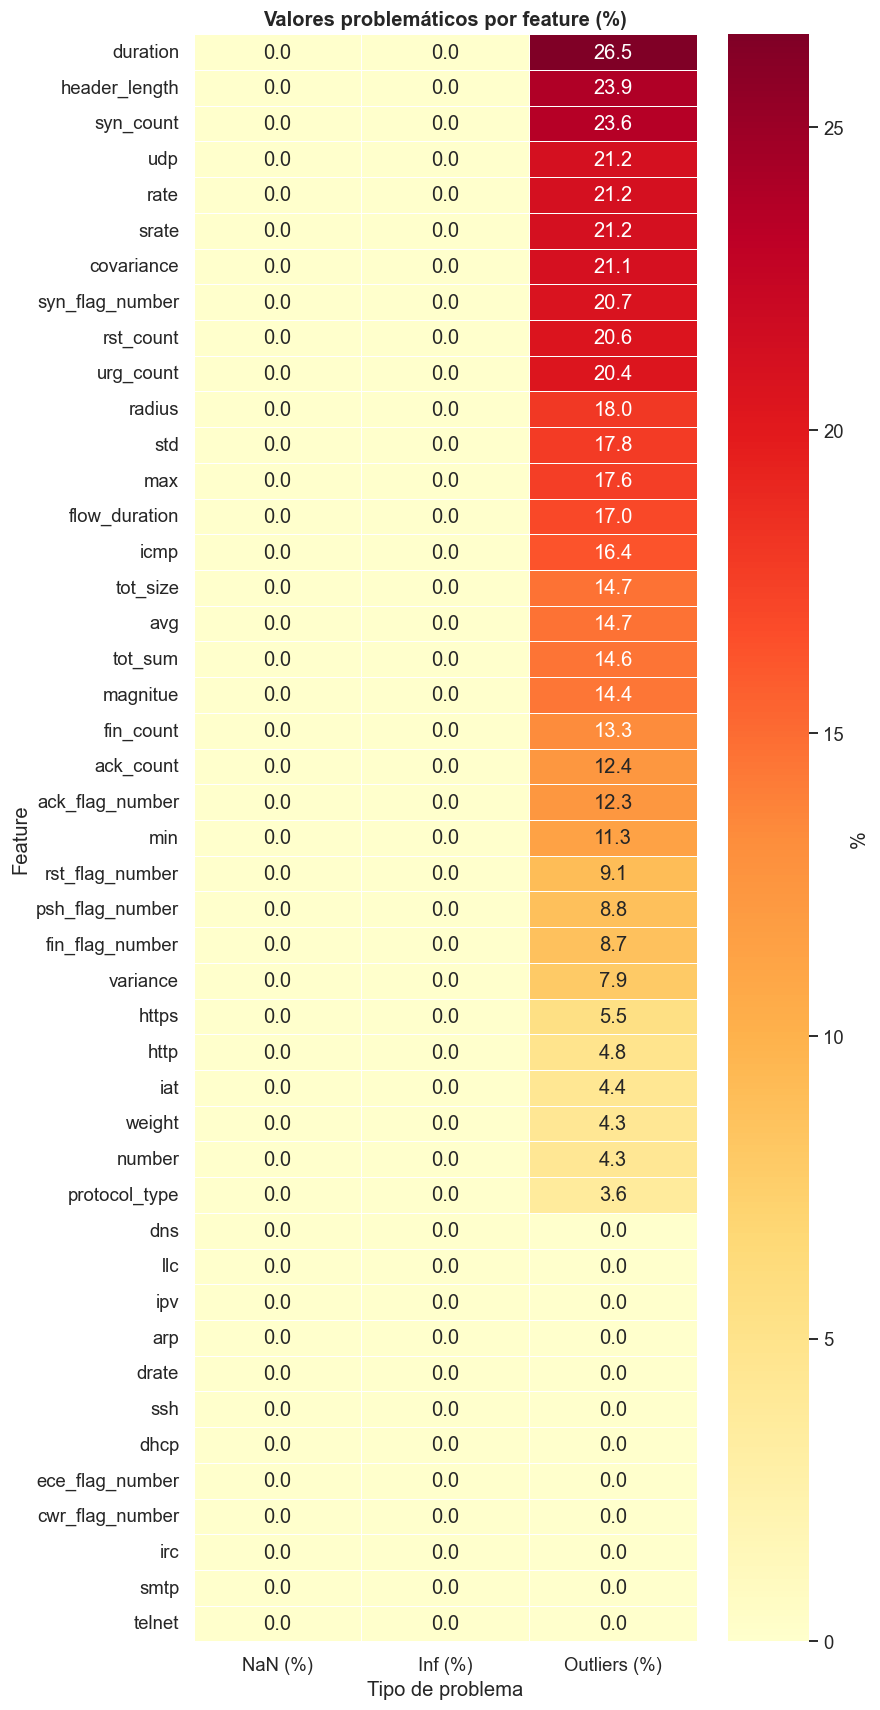

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización: heatmap de valores problemáticos
# ─────────────────────────────────────────────────────────────────────────────
problem_df: pd.DataFrame = pd.DataFrame({
    "NaN (%)": nan_counts[feature_cols] / len(df) * 100,
    "Inf (%)": inf_counts / len(df) * 100,
    "Outliers (%)": outlier_counts / len(df) * 100,
}).fillna(0)

# Filtrar solo features que tengan al menos algún valor problemático
problem_df = problem_df[problem_df.sum(axis=1) > 0]

if problem_df.empty:
    print("✓ Ninguna feature presenta NaN, Inf ni outliers extremos.")
else:
    fig, ax = plt.subplots(figsize=(8, max(4, len(problem_df) * 0.35)))
    sns.heatmap(
        problem_df.sort_values("Outliers (%)", ascending=False),
        annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.5, ax=ax, cbar_kws={"label": "%"}
    )
    ax.set_title(
        "Valores problemáticos por feature (%)",
        fontweight="bold"
    )
    ax.set_xlabel("Tipo de problema")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

## 7. Análisis de correlación entre features

Features altamente correlacionadas entre sí aportan información redundante
al modelo. Identificarlas permite reducir la dimensionalidad del vector de
entrada sin pérdida de poder discriminativo, lo cual es crítico para la
síntesis eficiente en FPGA.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Matriz de correlación de Pearson
#
# Para calcular la correlación se reemplaza Inf con NaN y se dropna
# para no contaminar el cálculo. Se usa una muestra representativa
# (50k filas) para agilizar el cómputo.
# ─────────────────────────────────────────────────────────────────────────────
CORR_SAMPLE_SIZE: int = 50_000

df_corr_input: pd.DataFrame = (
    df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    #.sample(n=min(CORR_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
)

corr_matrix: pd.DataFrame = df_corr_input.corr(method="pearson")

print(f"Matriz de correlación calculada sobre {len(df_corr_input):,} muestras.")
print(f"Dimensión: {corr_matrix.shape}")

Matriz de correlación calculada sobre 46,686,579 muestras.
Dimensión: (46, 46)


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Pares de features con alta correlación (|r| > umbral)
#
# Umbral de 0.90: correlación alta. Una de las dos
# features del par es candidata directa a eliminación en Hito 2.
# ─────────────────────────────────────────────────────────────────────────────
CORR_THRESHOLD: float = 0.90

# Extraer la mitad superior de la matriz (evitar duplicados)
upper_tri: pd.DataFrame = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs: pd.DataFrame = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "pearson_r"})
    .query(f"abs(pearson_r) >= {CORR_THRESHOLD}")
    .sort_values("pearson_r", ascending=False)
)

print(f"Pares con |r| ≥ {CORR_THRESHOLD}: {len(high_corr_pairs)}")
if not high_corr_pairs.empty:
    print("\nTop pares altamente correlacionados:")
    print(high_corr_pairs.to_string(index=False))

Pares con |r| ≥ 0.9: 16

Top pares altamente correlacionados:
      feature_a       feature_b  pearson_r
           rate           srate     1.0000
            ipv             llc     1.0000
            std          radius     1.0000
         number          weight     0.9996
            iat          weight     0.9973
            iat          number     0.9960
fin_flag_number       ack_count     0.9859
fin_flag_number rst_flag_number     0.9756
            avg        magnitue     0.9684
rst_flag_number       ack_count     0.9620
            max             std     0.9526
            max          radius     0.9526
            avg        tot_size     0.9410
        tot_sum             avg     0.9342
       tot_size        magnitue     0.9292
        tot_sum        magnitue     0.9226


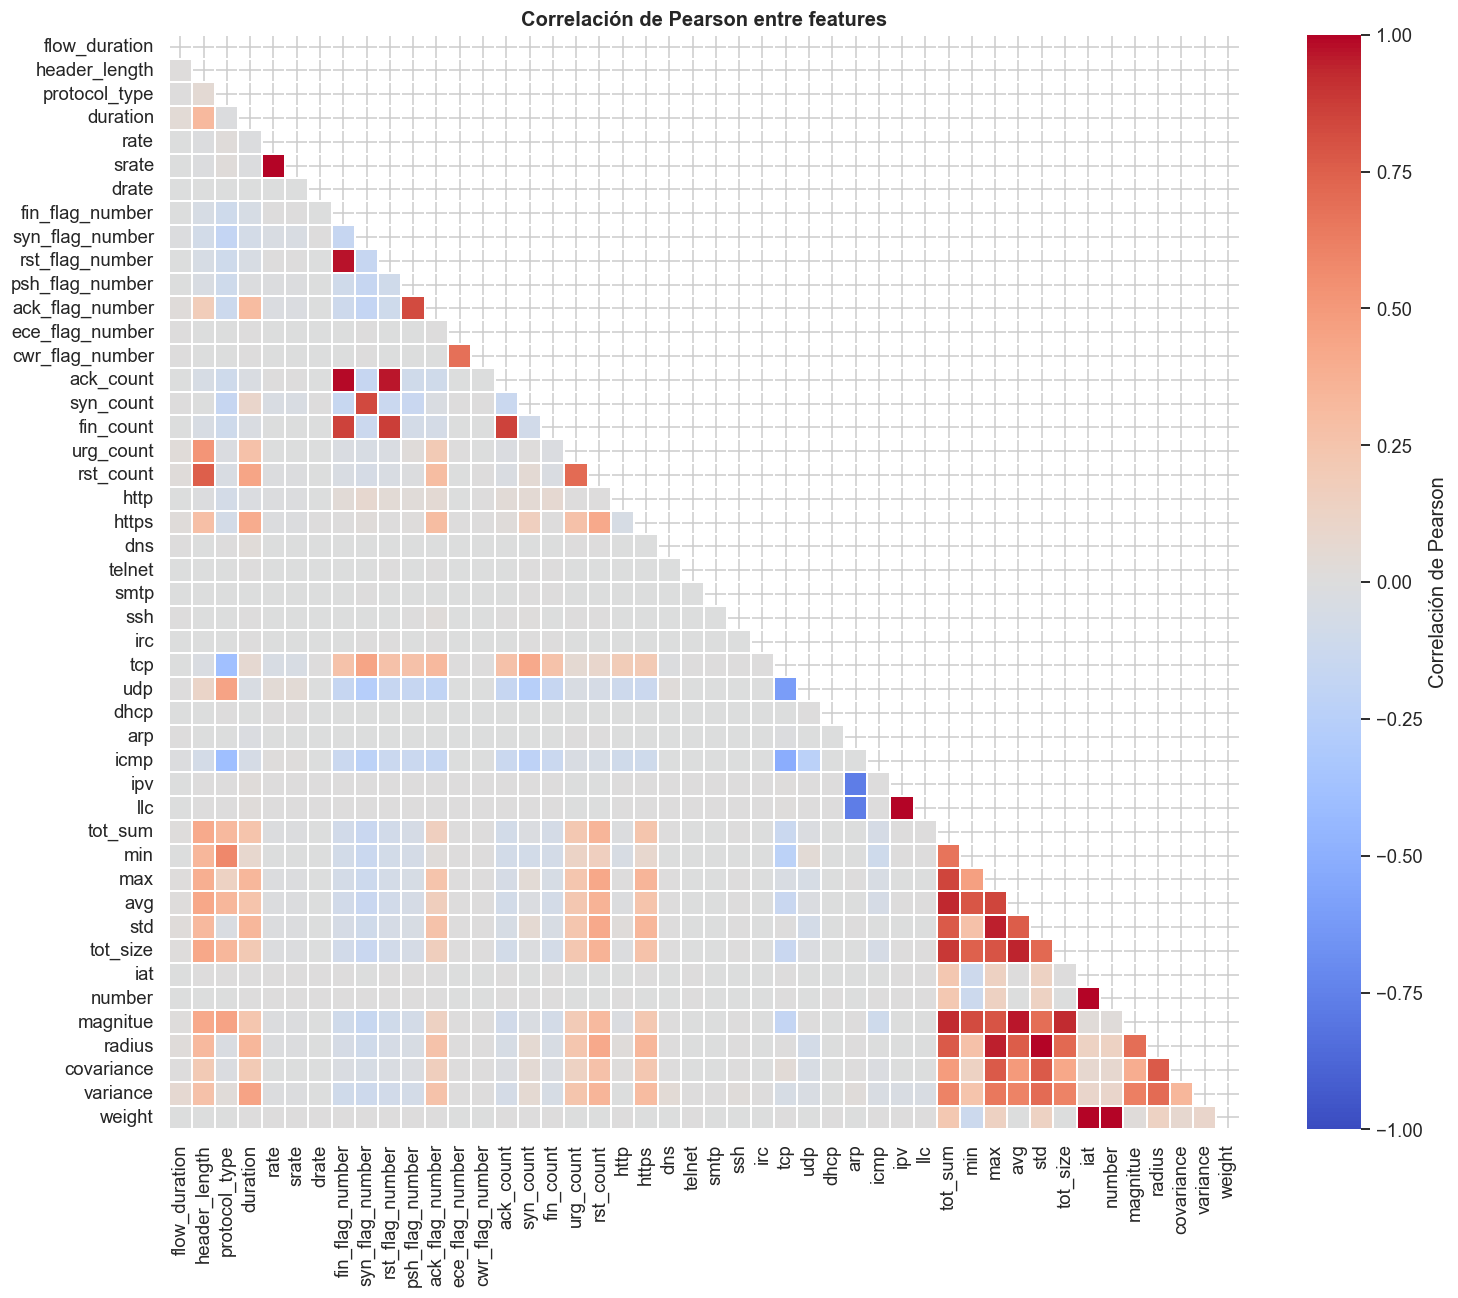

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización: heatmap de correlación
#
# Si hay muchas features, se muestra solo el subconjunto con mayor
# varianza para mantener el gráfico legible.
# ─────────────────────────────────────────────────────────────────────────────
MAX_FEATURES_HEATMAP: int = 47

if len(feature_cols) > MAX_FEATURES_HEATMAP:
    # Seleccionar las features de mayor varianza (más informativas)
    top_var_features: list[str] = (
        df_corr_input.var()
        .nlargest(MAX_FEATURES_HEATMAP)
        .index.tolist()
    )
    corr_plot: pd.DataFrame = corr_matrix.loc[top_var_features, top_var_features]
    title_suffix: str = f" (top {MAX_FEATURES_HEATMAP} por varianza)"
else:
    corr_plot = corr_matrix
    title_suffix = ""

mask: np.ndarray = np.triu(np.ones_like(corr_plot, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_plot,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=len(corr_plot) <= 15,  # Anotar valores solo si hay pocas features
    fmt=".2f",
    ax=ax,
    cbar_kws={"label": "Correlación de Pearson"}
)
ax.set_title(
    f"Correlación de Pearson entre features{title_suffix}",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8. Distribución de features clave por clase

Este análisis evalúa el **poder discriminativo** de cada feature:
una feature con distribuciones claramente separadas entre clases es
candidata prioritaria para el vector de entrada del modelo.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Selección de features a analizar
#
# Se analiza el subconjunto de features candidatas del dominio de red.
# Si alguna no existe en el dataset, se omite con un aviso.
# ─────────────────────────────────────────────────────────────────────────────
CANDIDATE_FEATURES: list[str] = [
    # Tiempo y volumen 
    "flow_duration", "header_length", "duration", "iat", "rate", "srate",
    "tot_sum", "tot_size", "avg", "std", "min", "max", "number", "magnitue", 
    "radius", "covariance", "variance", "weight",
    # Flags TCP y conteos 
    "syn_flag_number", "rst_flag_number", "ack_flag_number",
    "fin_flag_number", "psh_flag_number",
    "ack_count", "syn_count", "fin_count", "rst_count", "urg_count",
    # Protocolos
    "protocol_type", "tcp", "udp", "icmp",
    # Aplicación 
    "http", "https", "ipv", "llc",
]

available_candidates: list[str] = [f for f in CANDIDATE_FEATURES if f in feature_cols]
missing_candidates:  list[str] = [f for f in CANDIDATE_FEATURES if f not in feature_cols]

print(f"Features candidatas disponibles : {len(available_candidates)} / {len(CANDIDATE_FEATURES)}")
if missing_candidates:
    print(f"⚠️  No encontradas en el dataset : {missing_candidates}")

Features candidatas disponibles : 36 / 36


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Estadísticas por clase para cada feature candidata
#
# Permite identificar rápidamente qué features separan bien las clases
# sin necesidad de visualizar cada una individualmente.
# ─────────────────────────────────────────────────────────────────────────────
if available_candidates:
    stats_by_class: pd.DataFrame = (
        df[available_candidates + [LABEL_COL]]
        .groupby(LABEL_COL)
        .agg(["mean", "median", "std"])
        .round(4)
    )
    print("Estadísticas (mean / median / std) por clase — features candidatas:")
    stats_by_class

Estadísticas (mean / median / std) por clase — features candidatas:


Calculando percentiles por clase (único groupby)...
✓ Percentiles calculados para 36 features × 34 clases.


Graficando features:   0%|          | 0/36 [00:00<?, ?it/s]

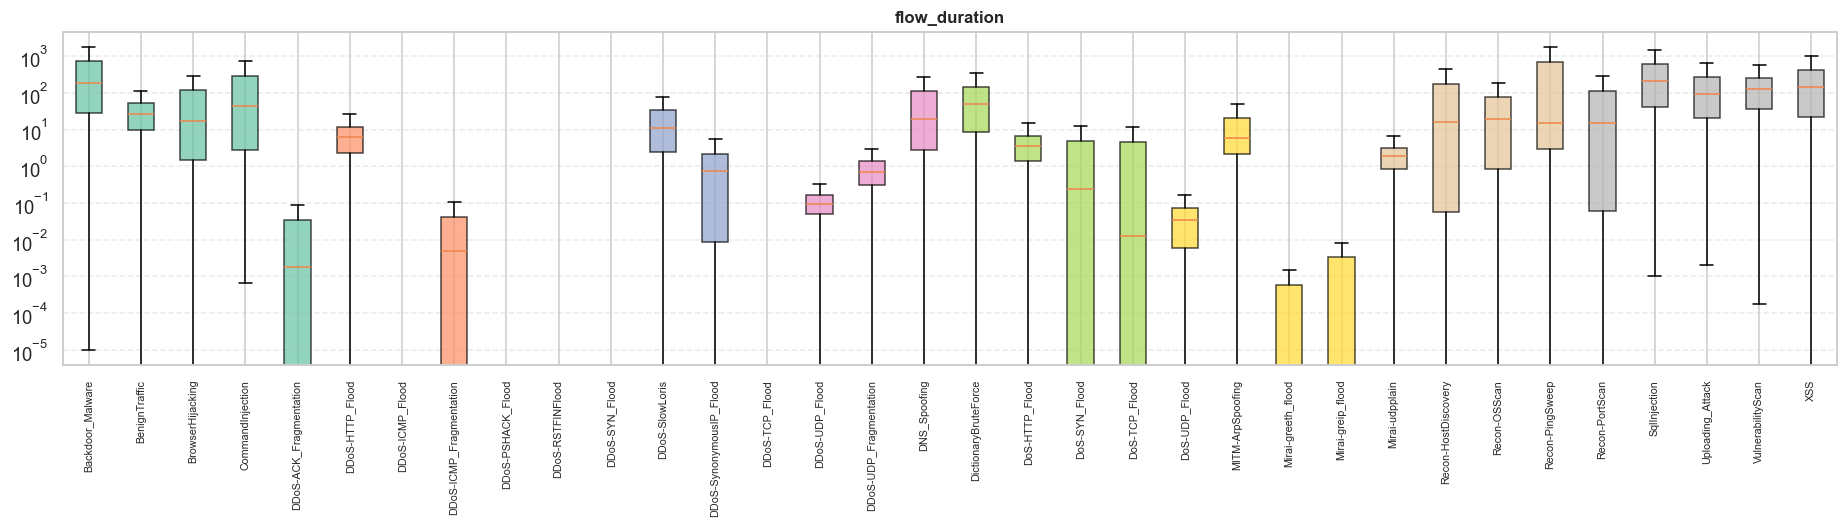

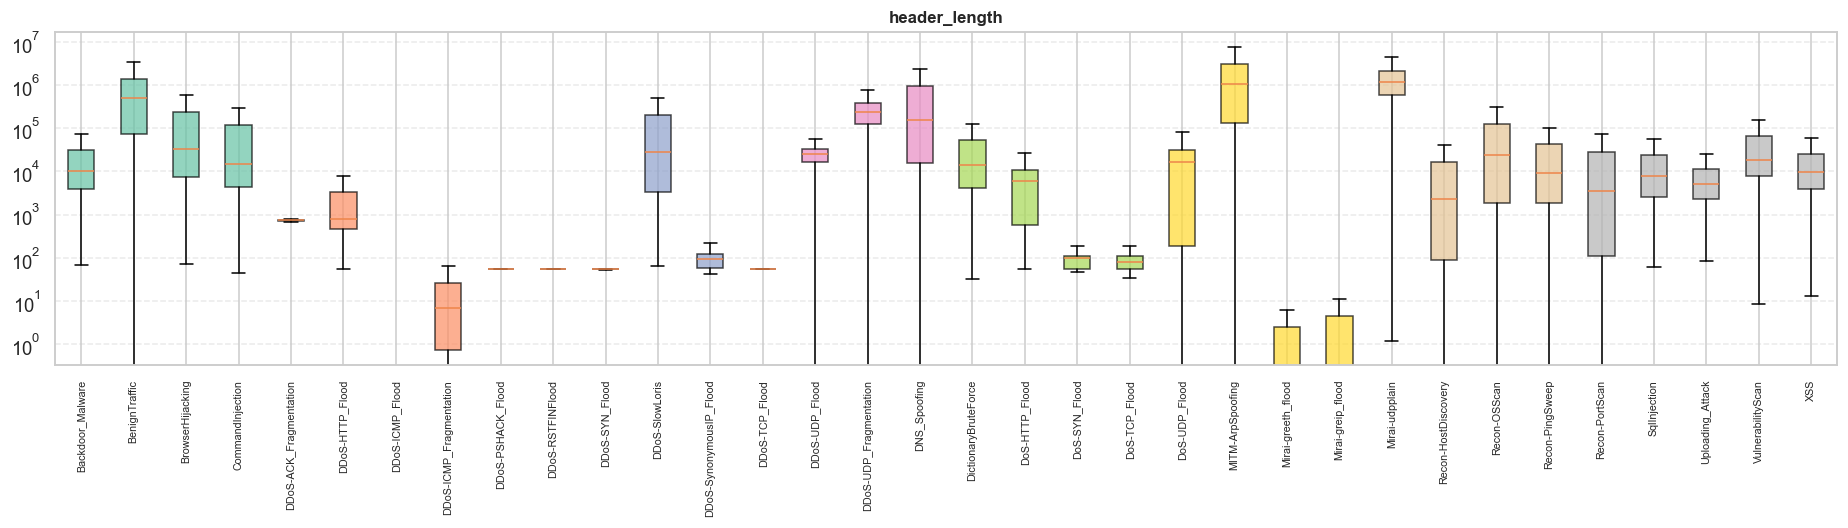

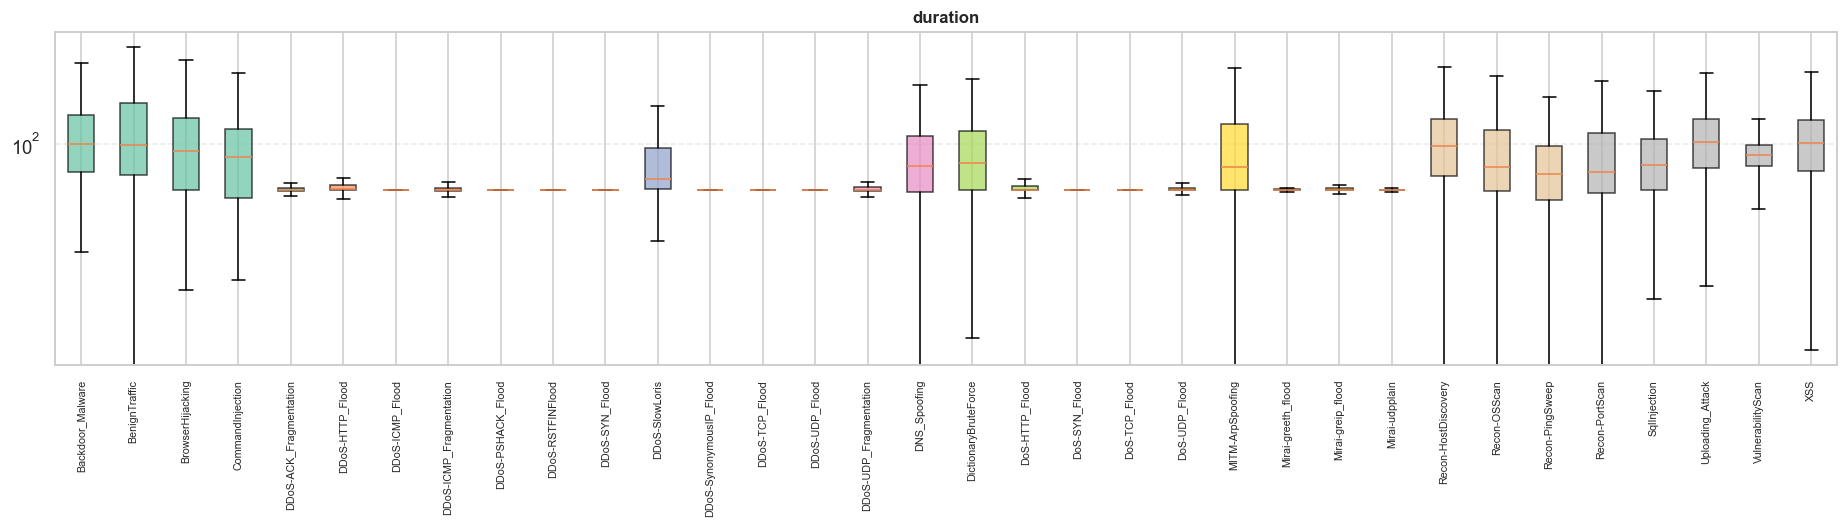

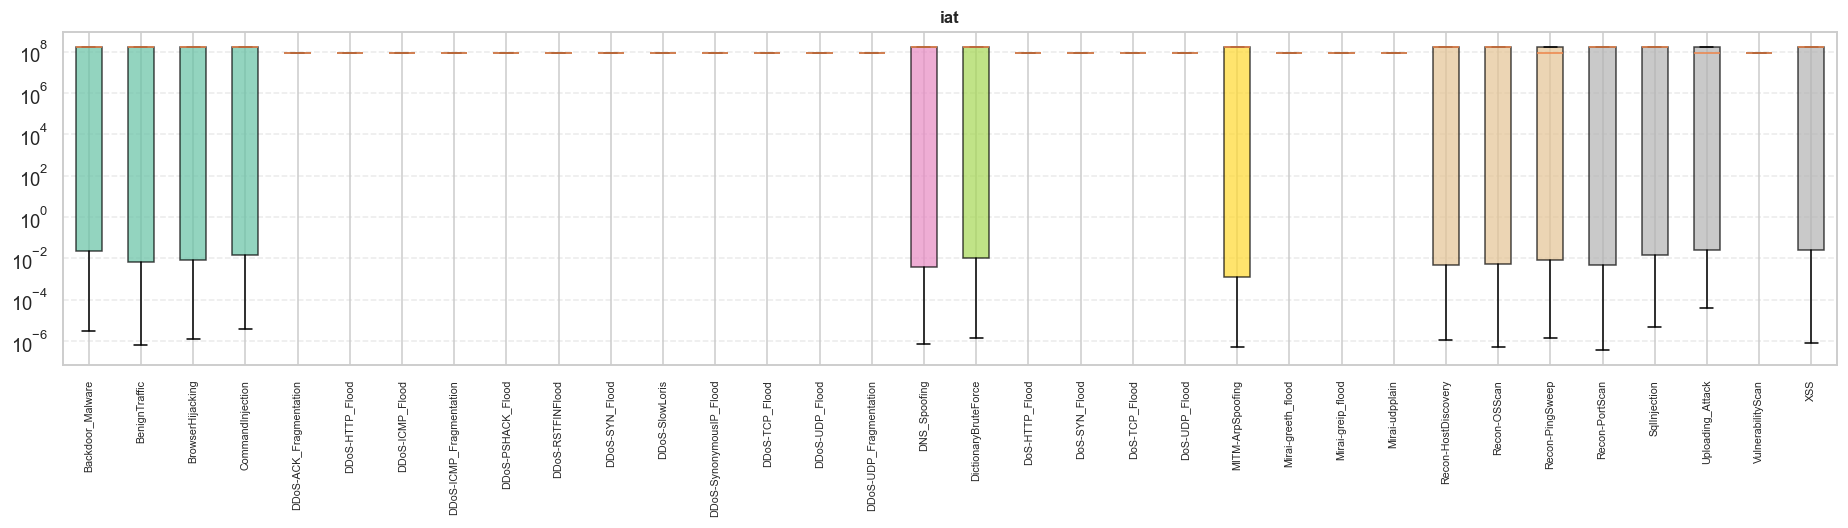

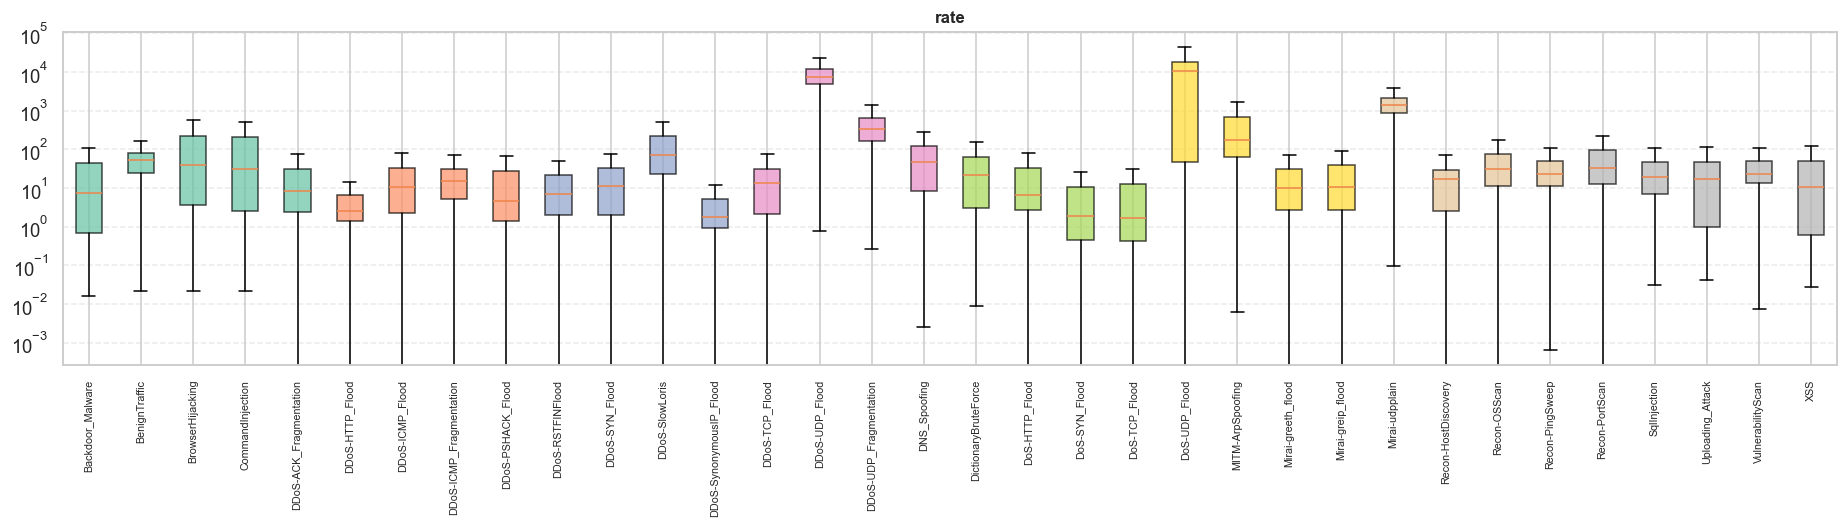

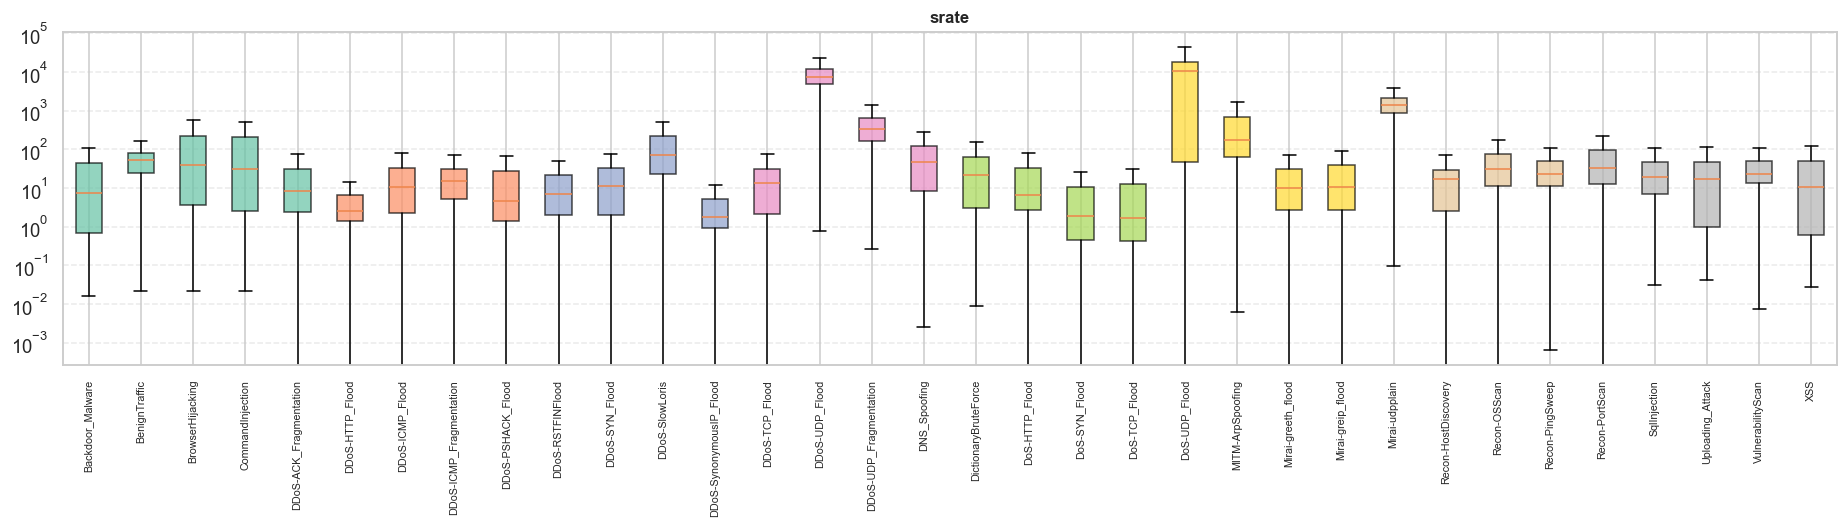

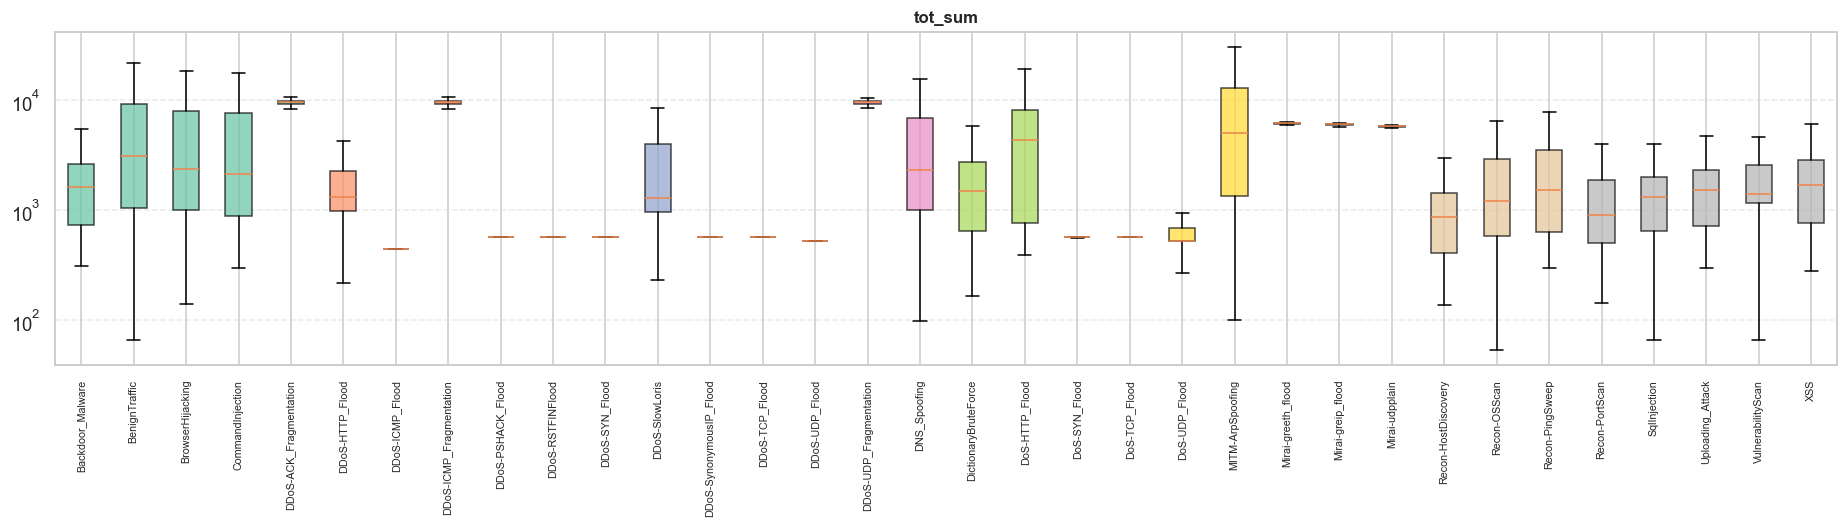

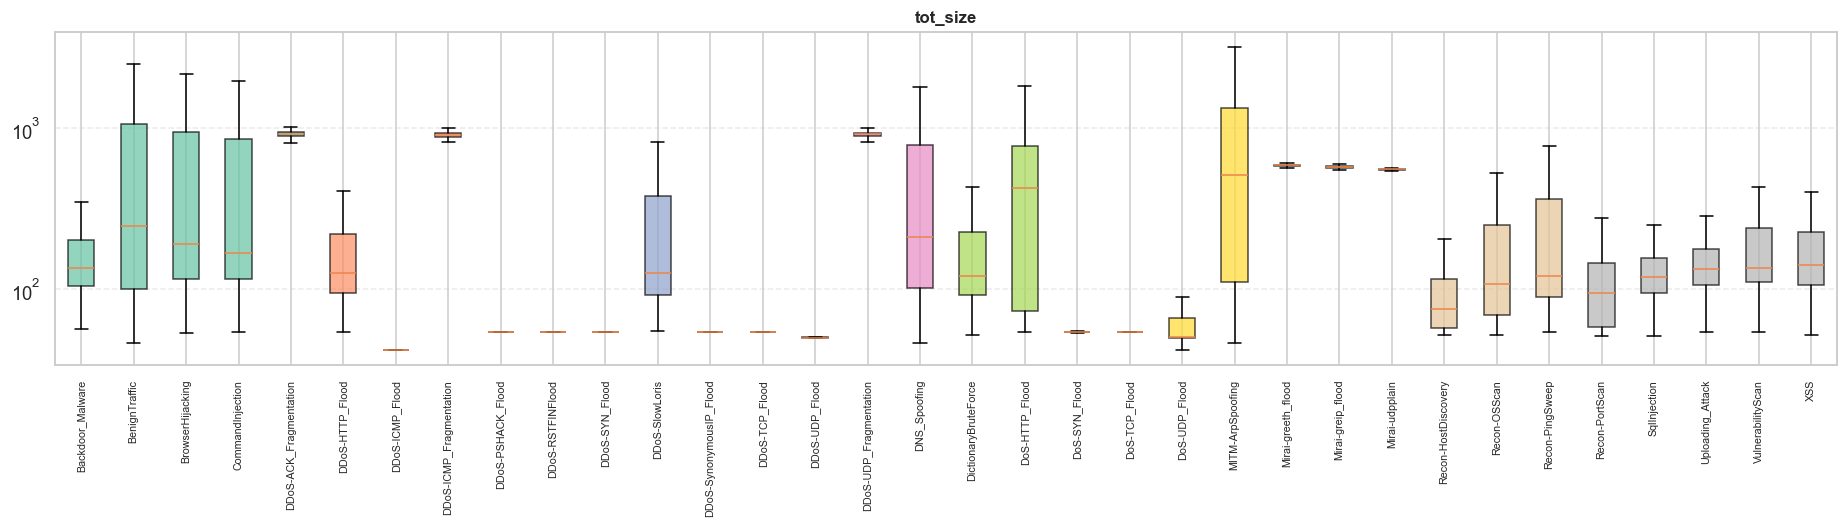

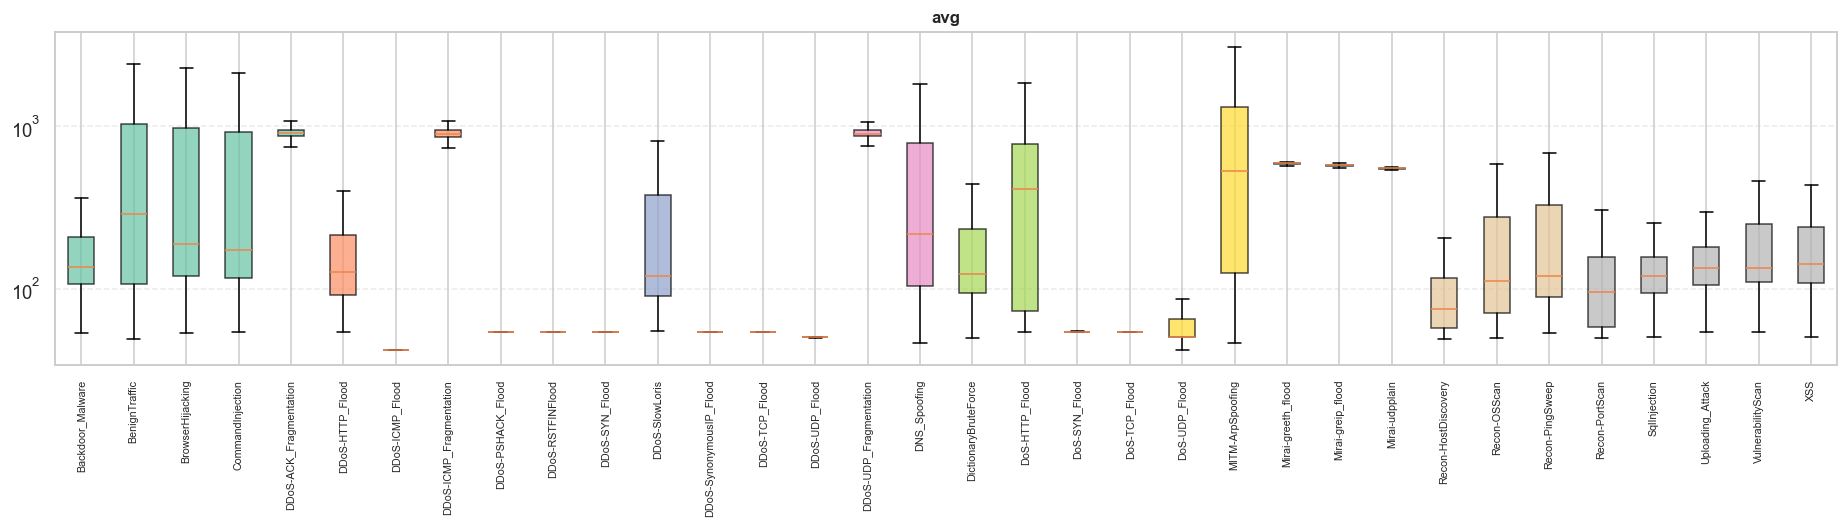

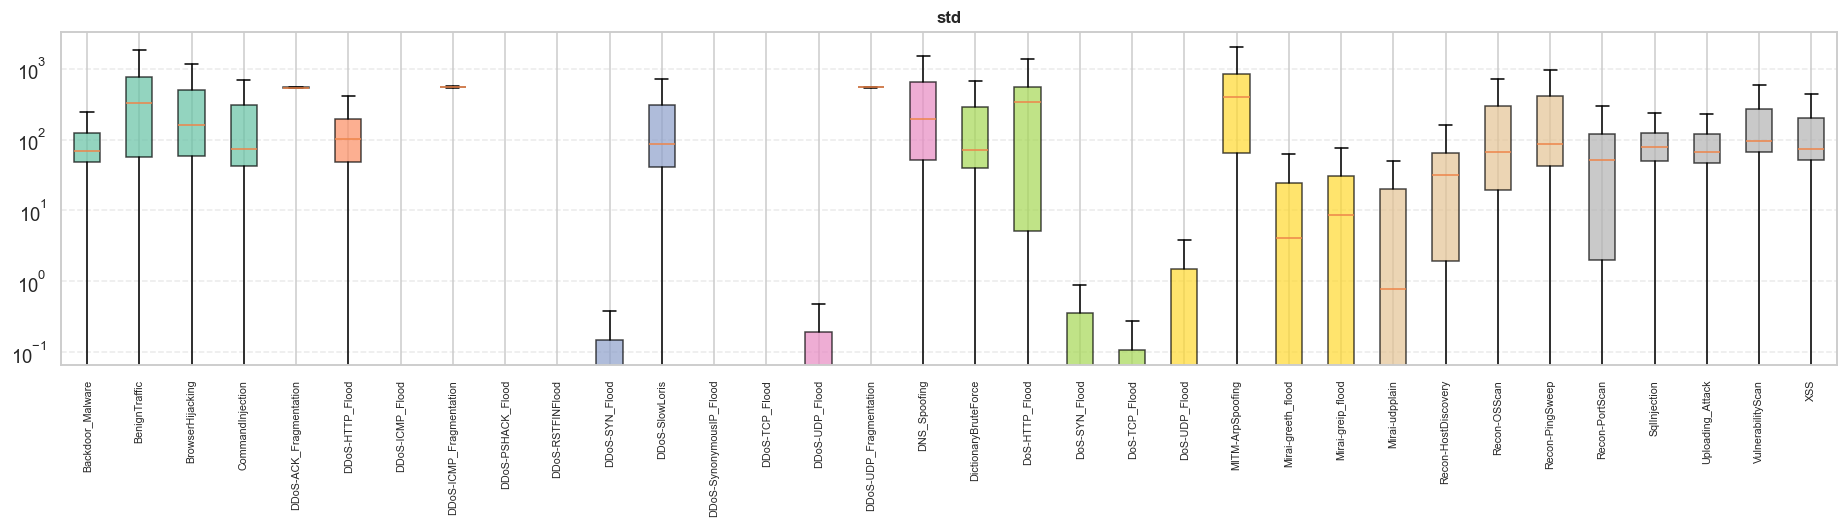

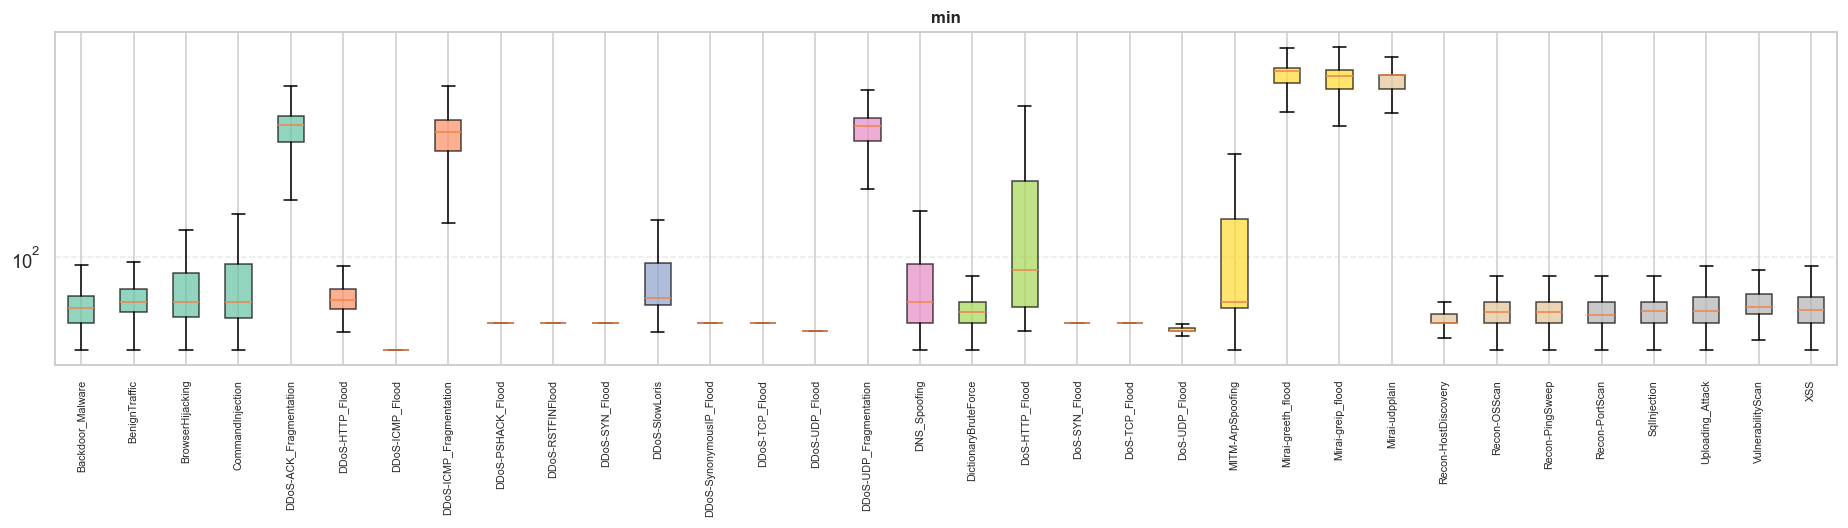

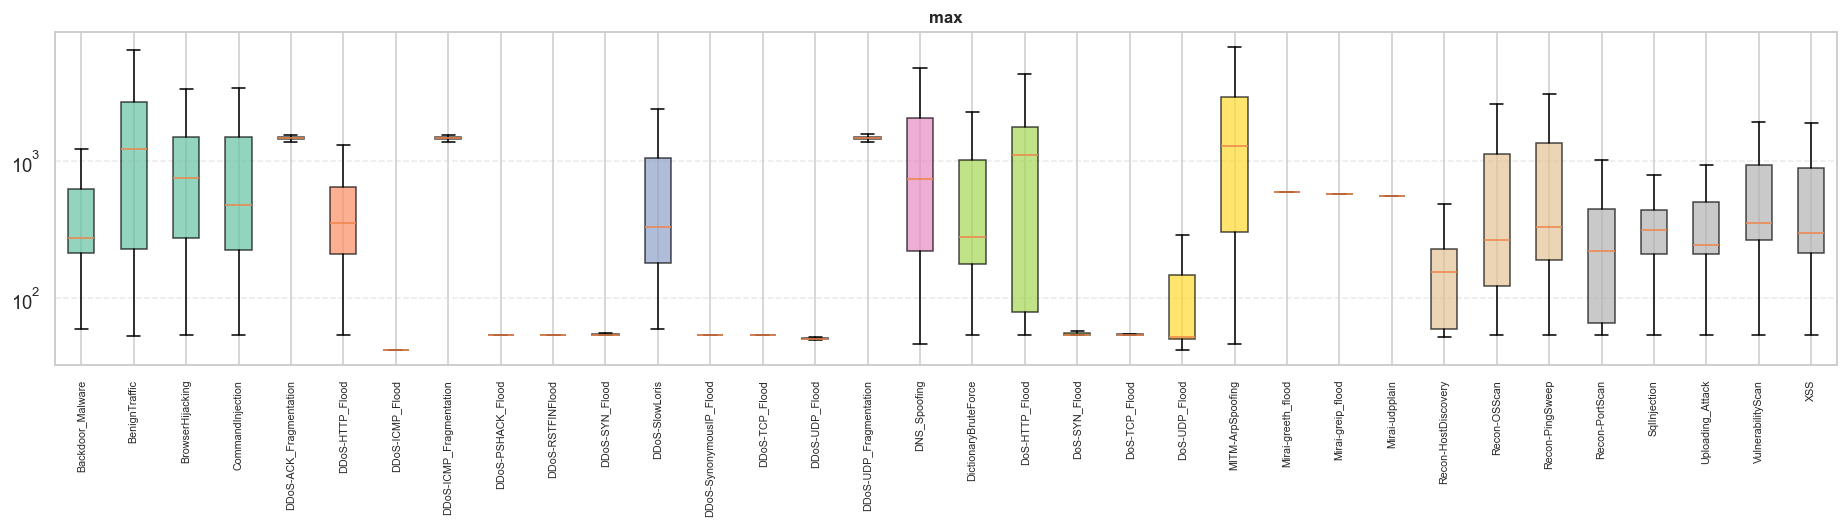

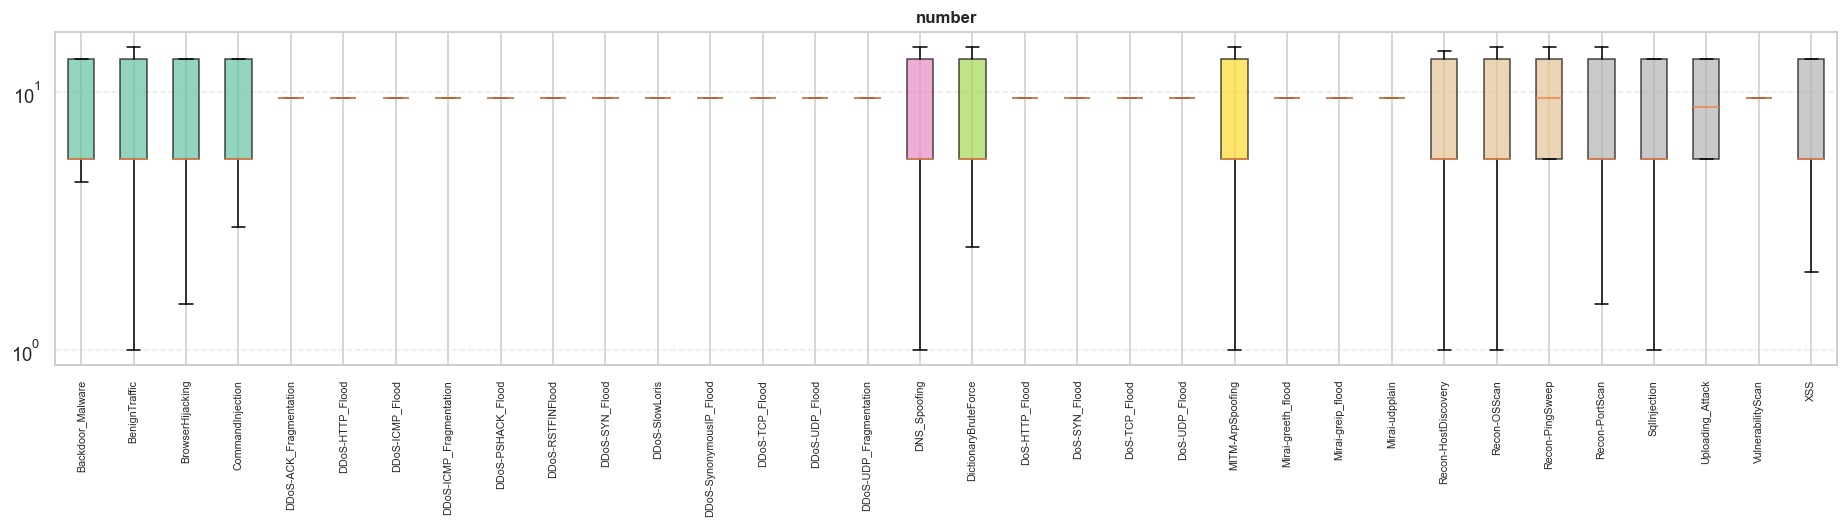

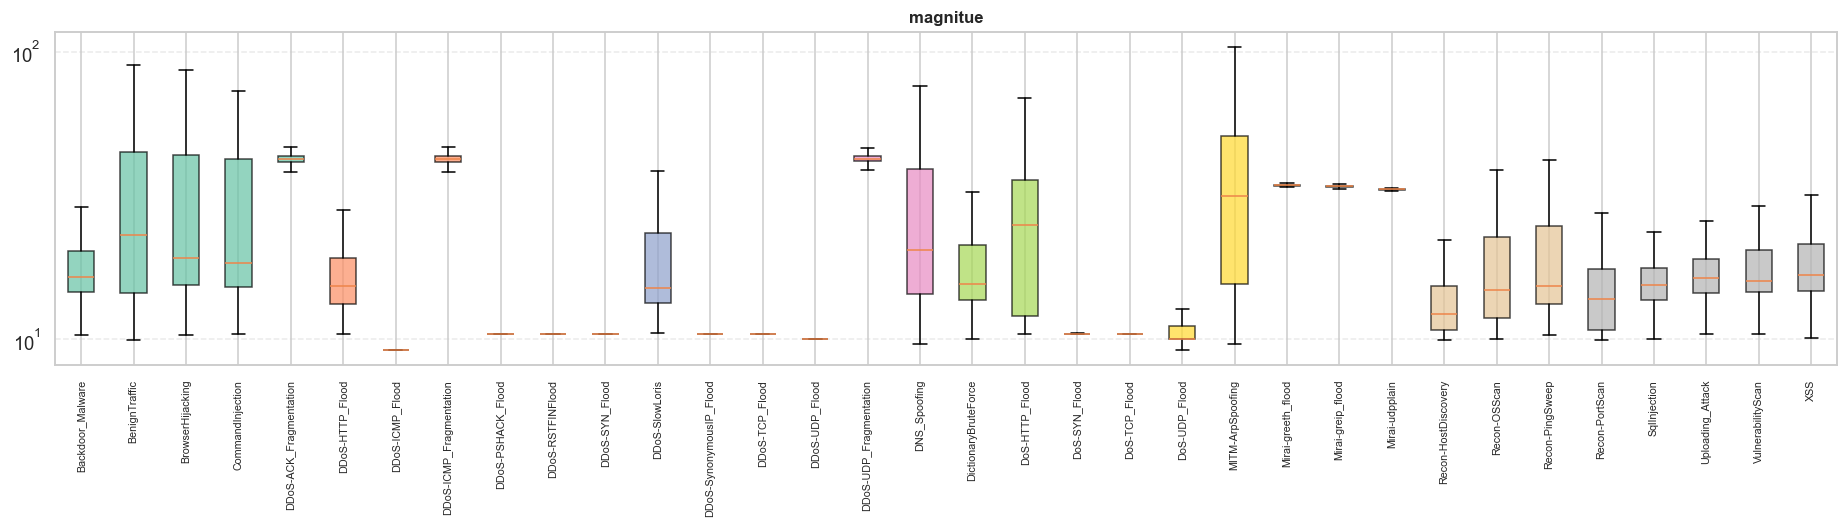

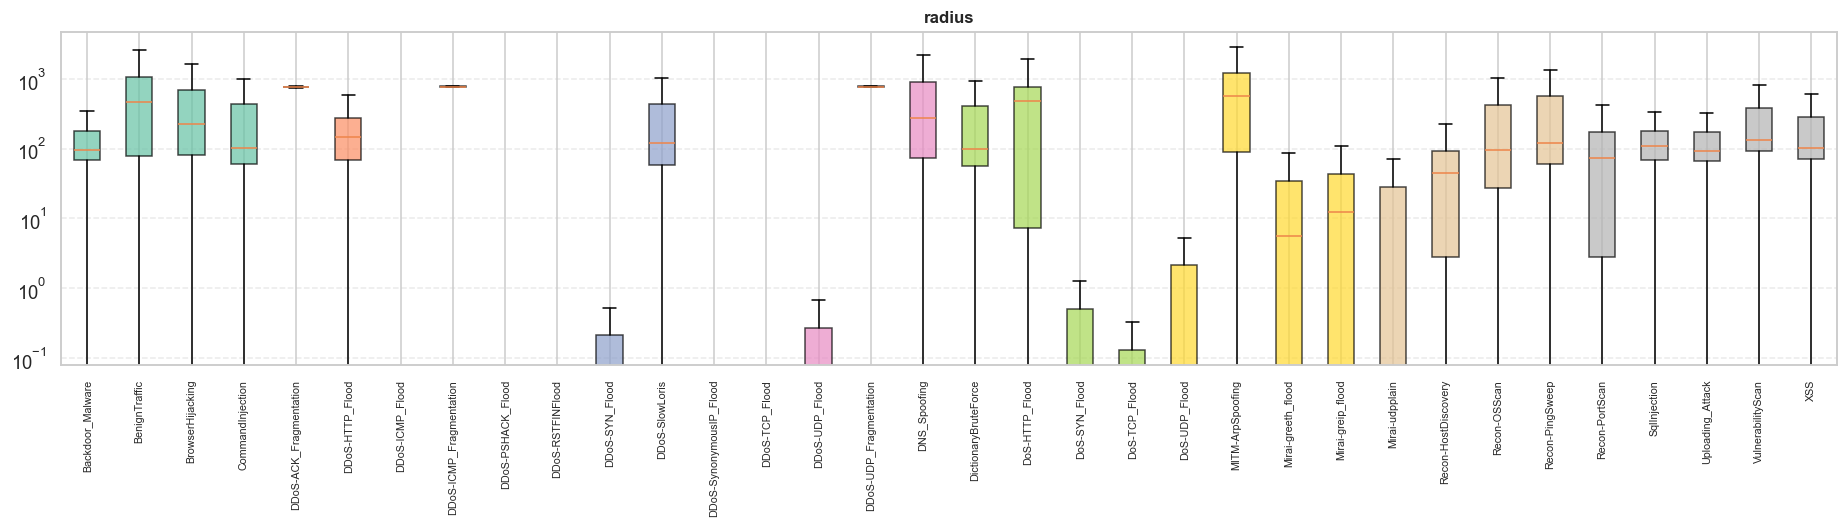

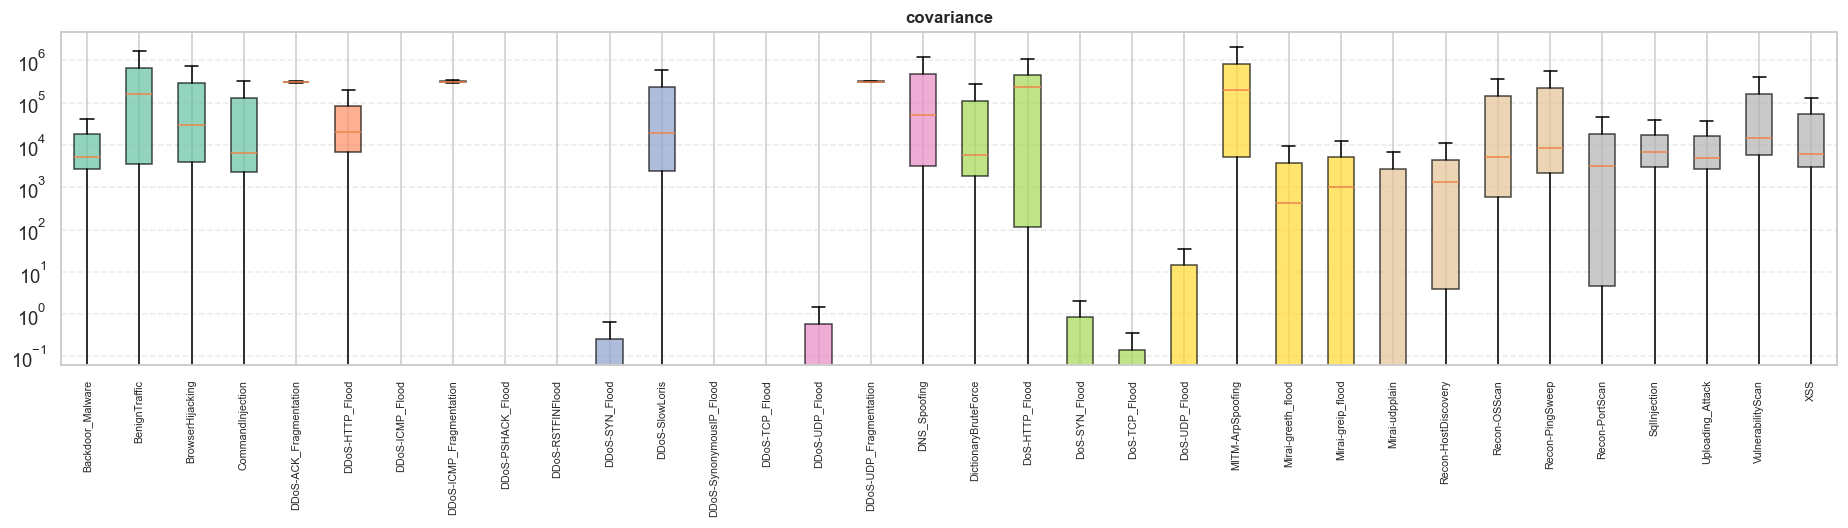

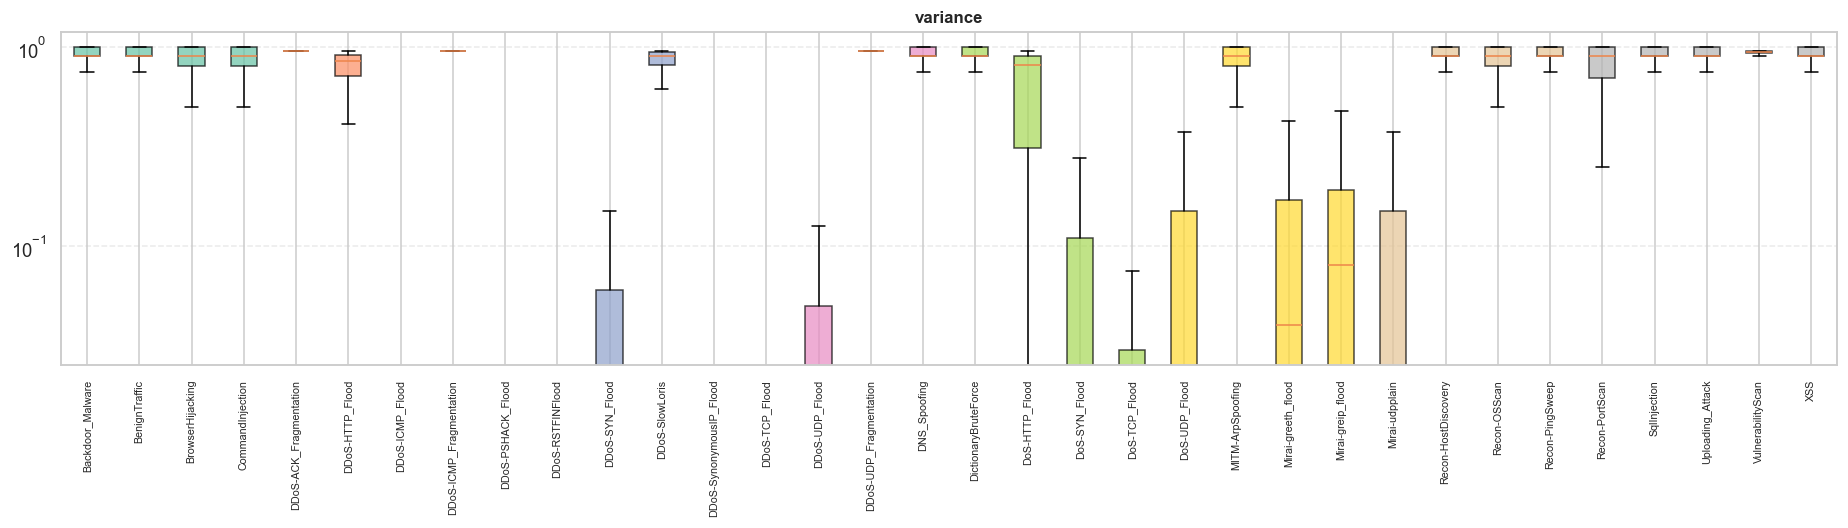

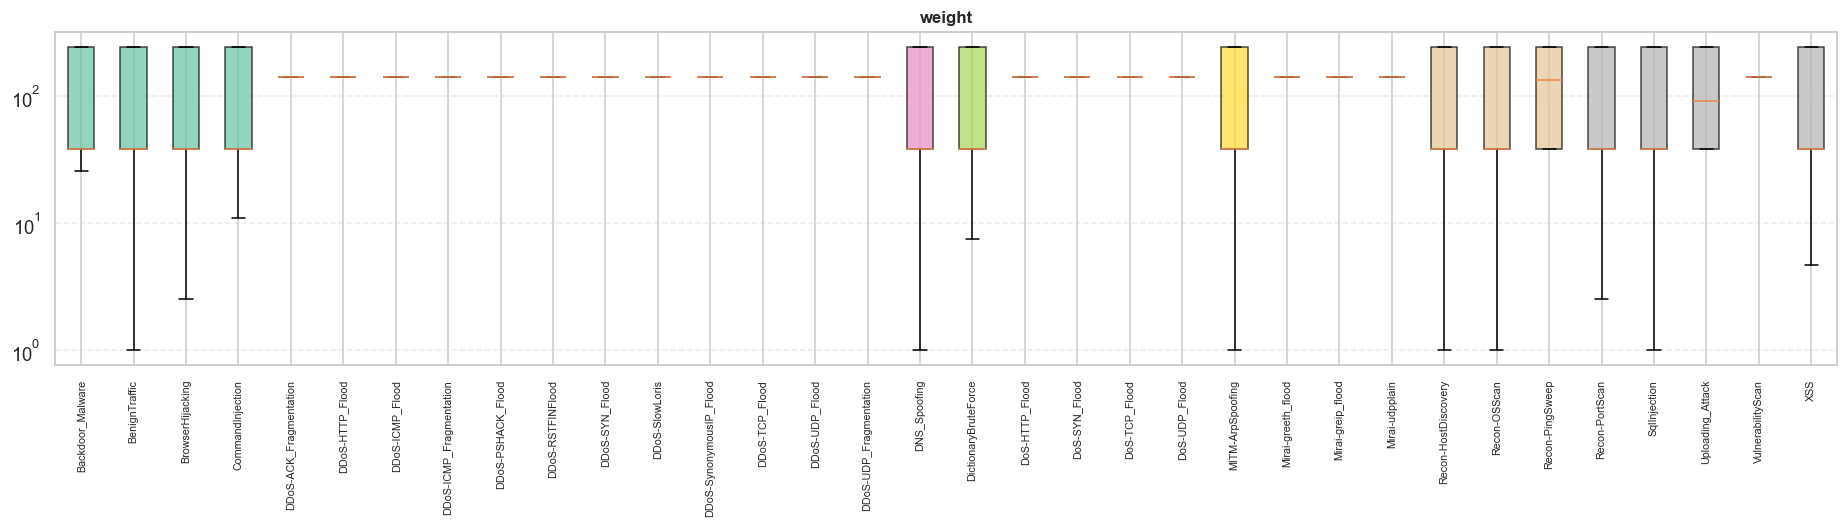

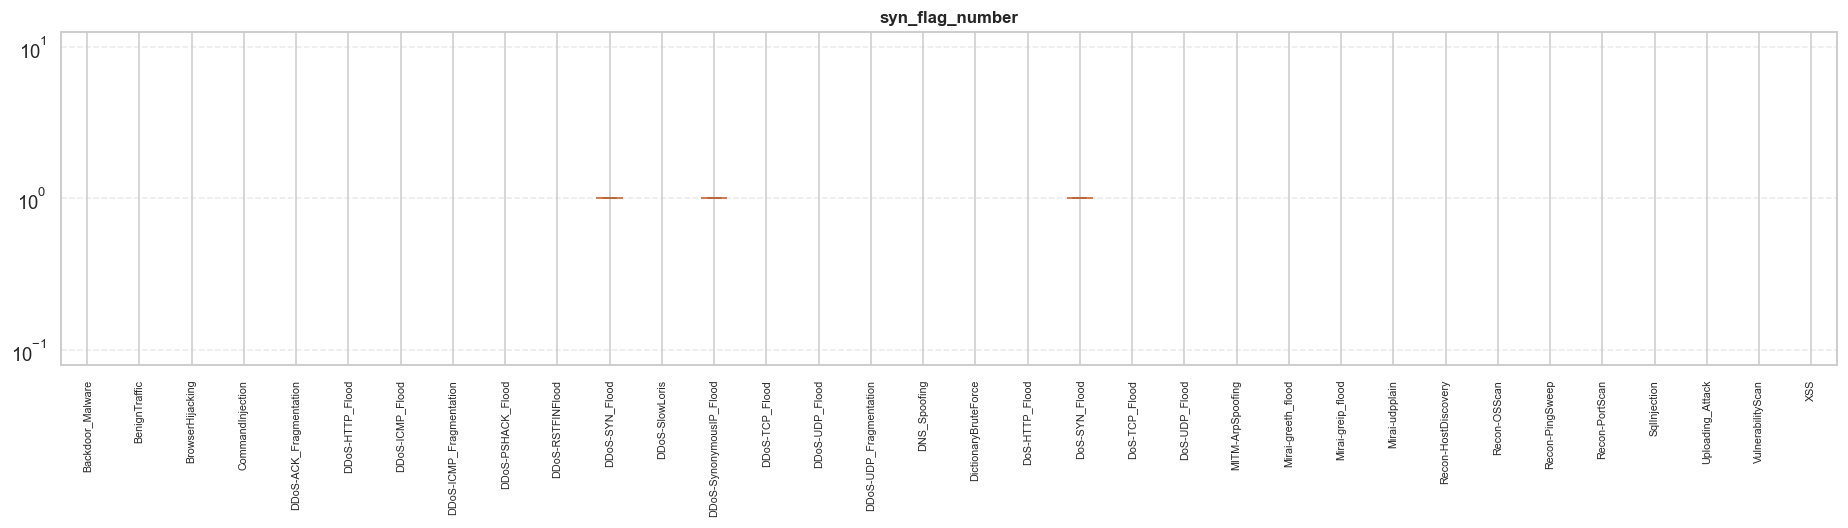

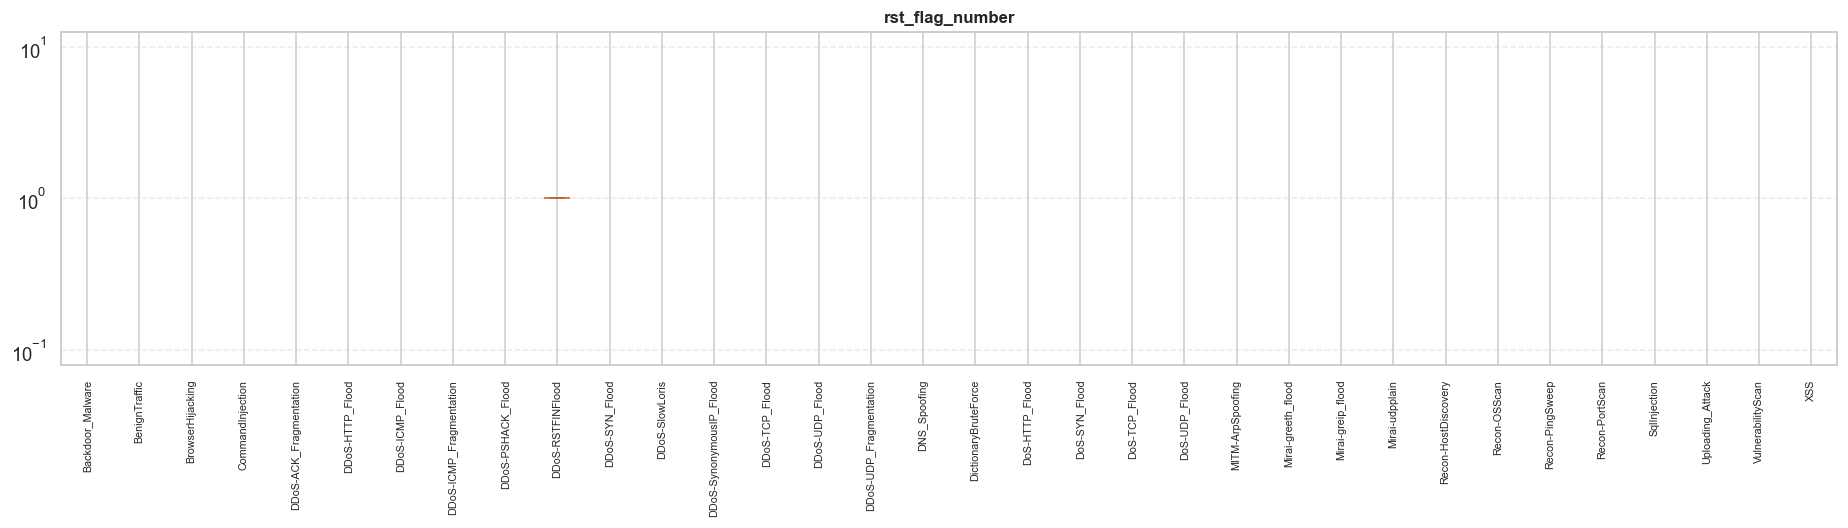

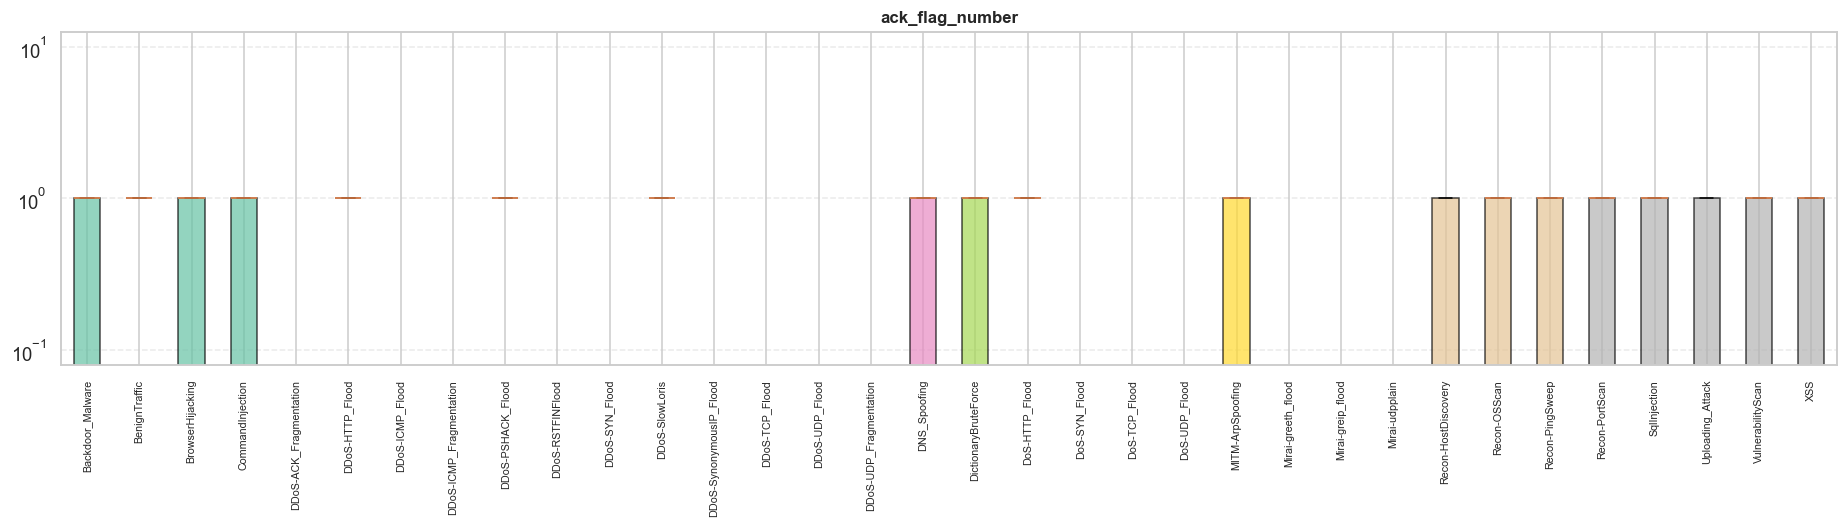

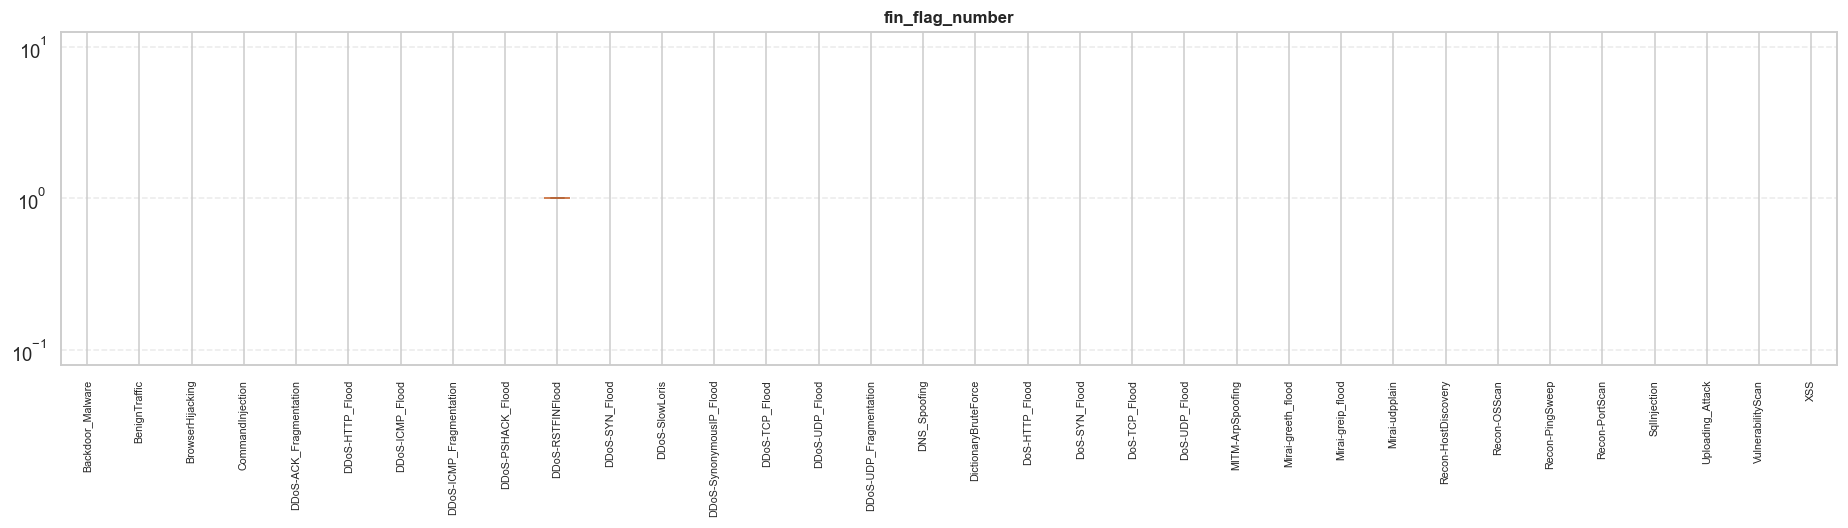

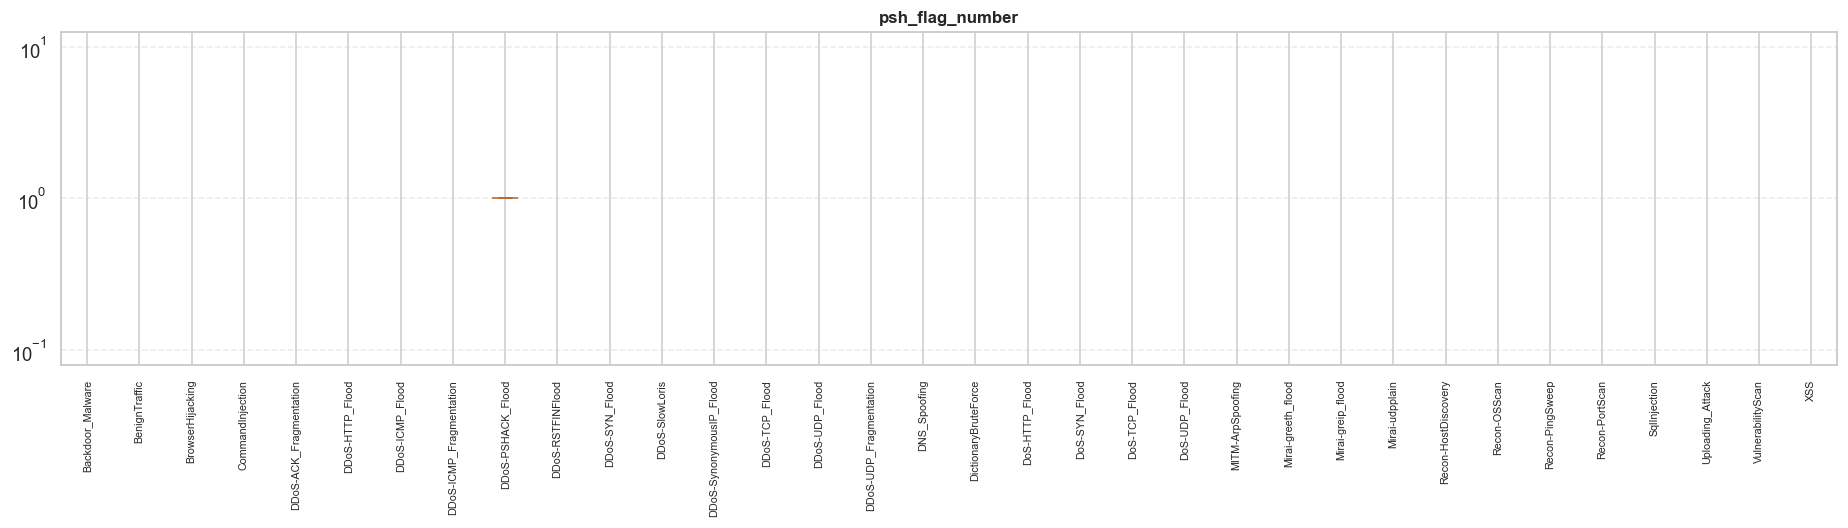

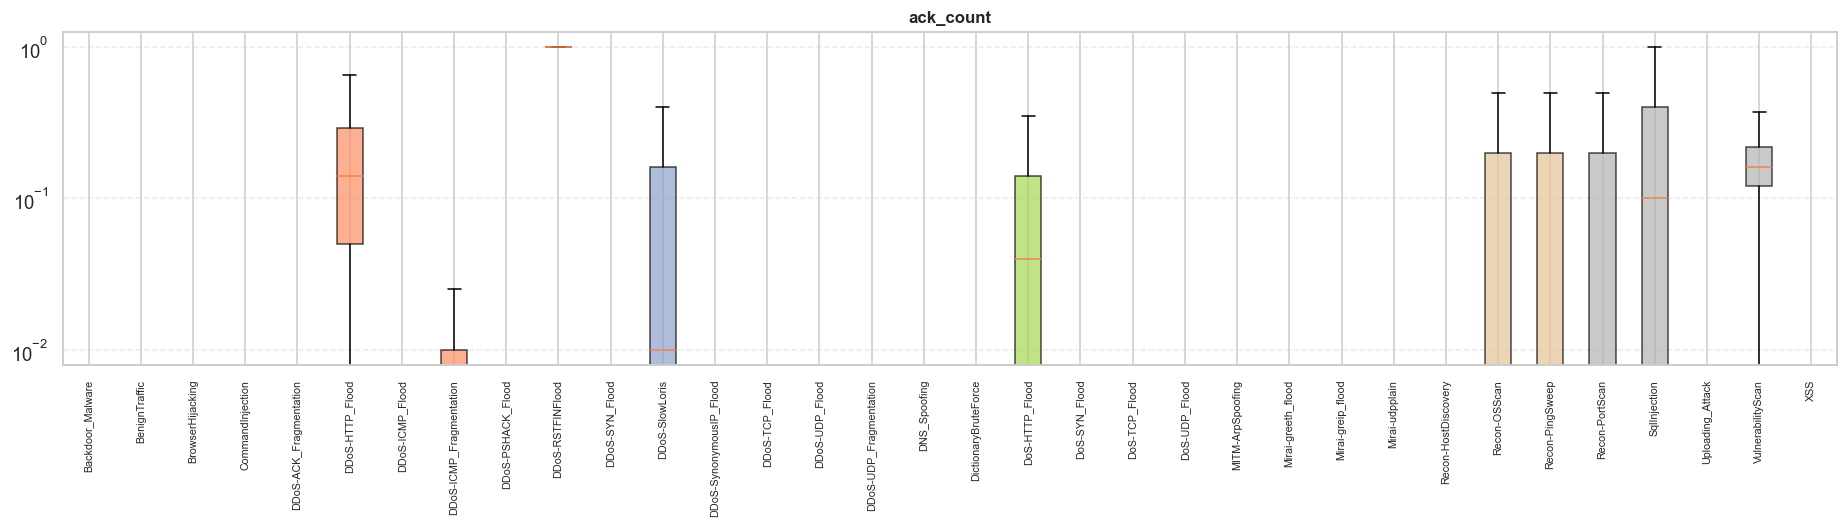

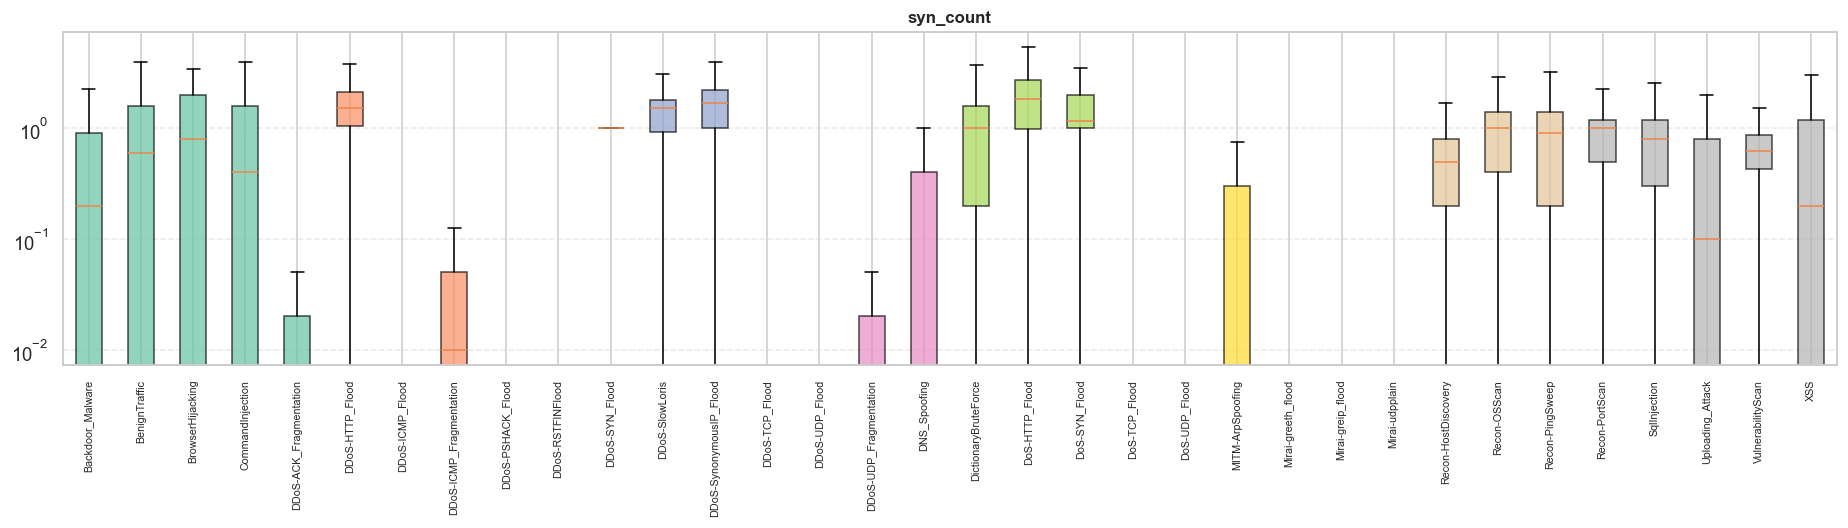

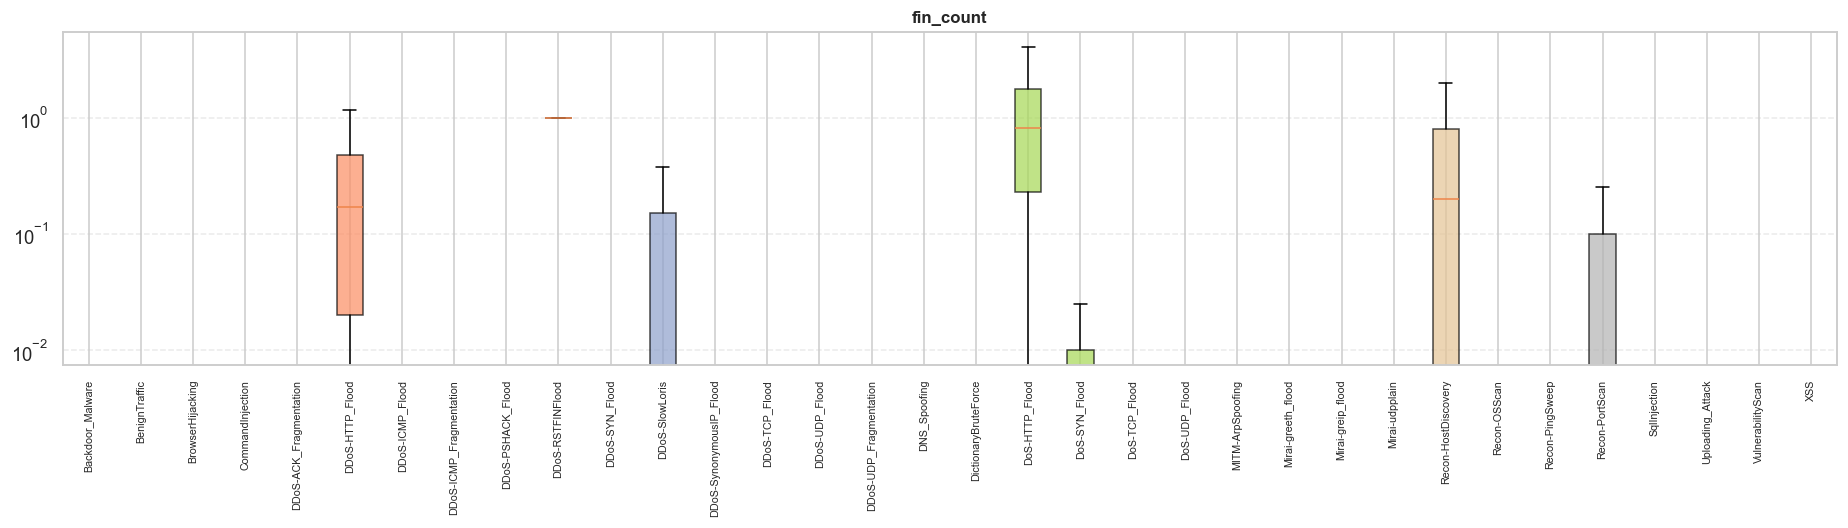

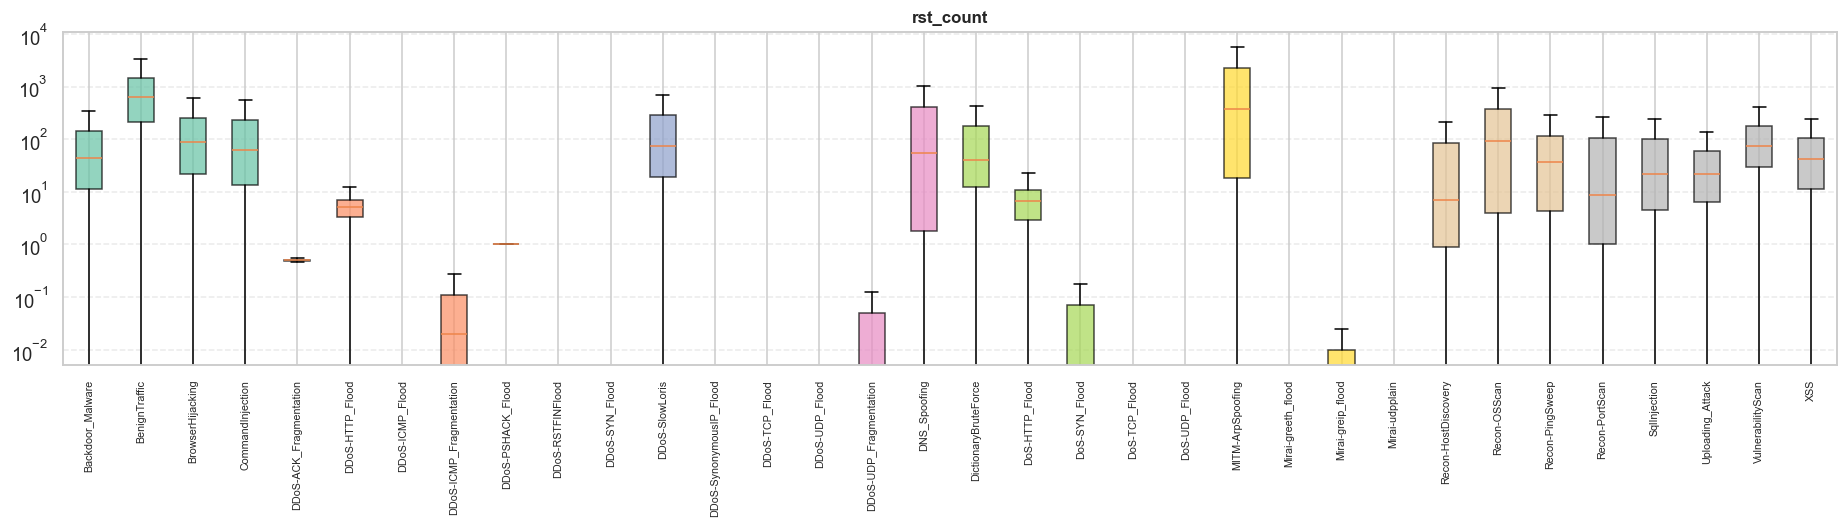

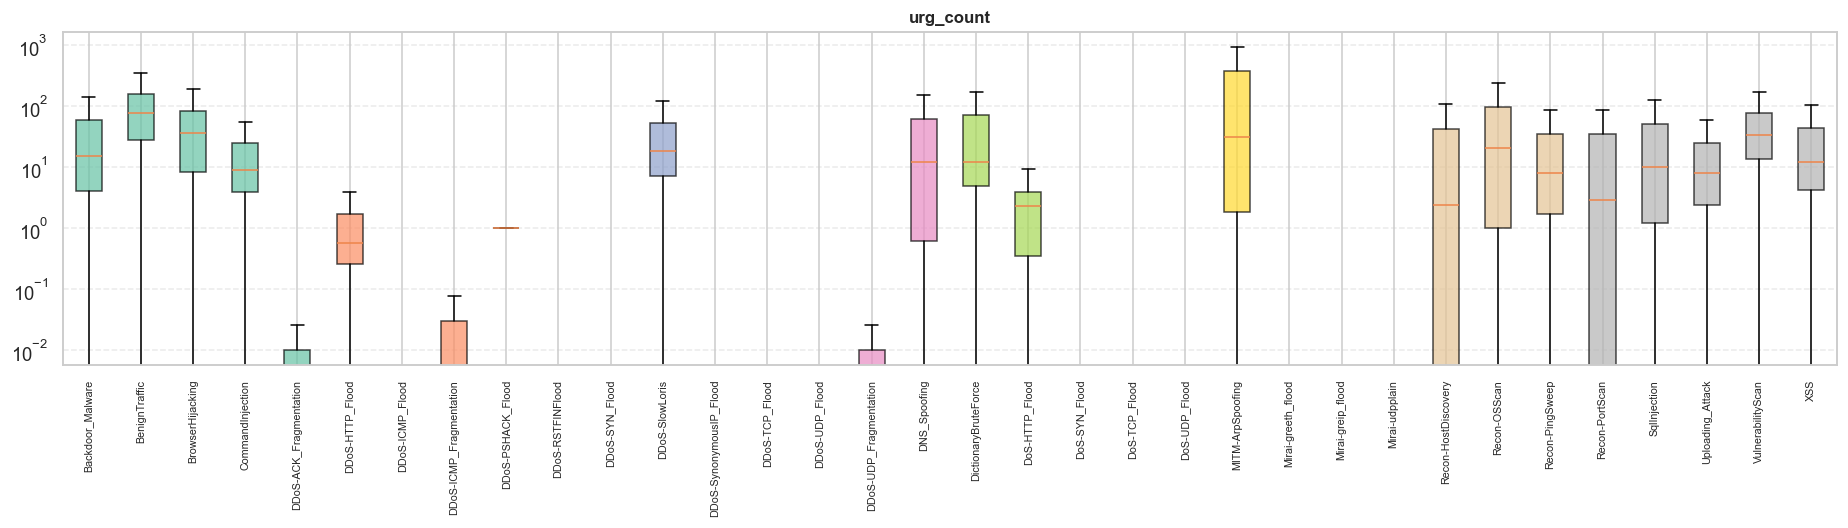

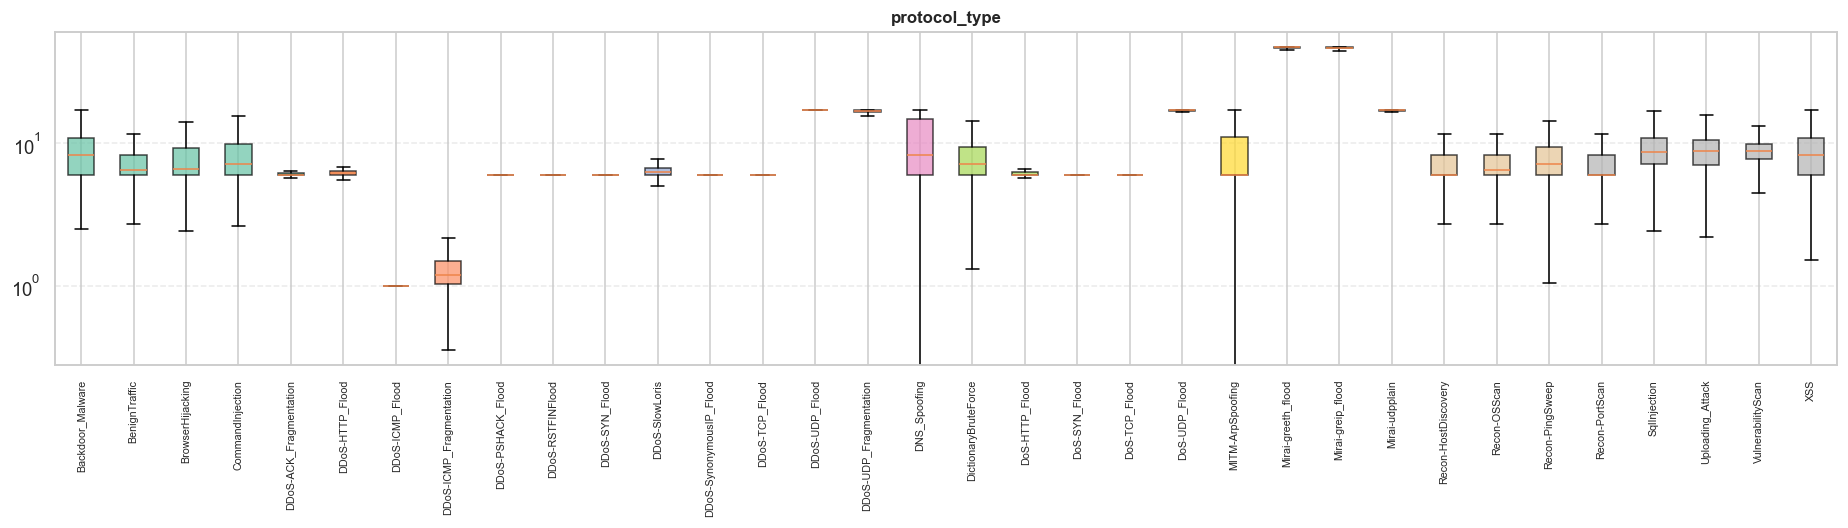

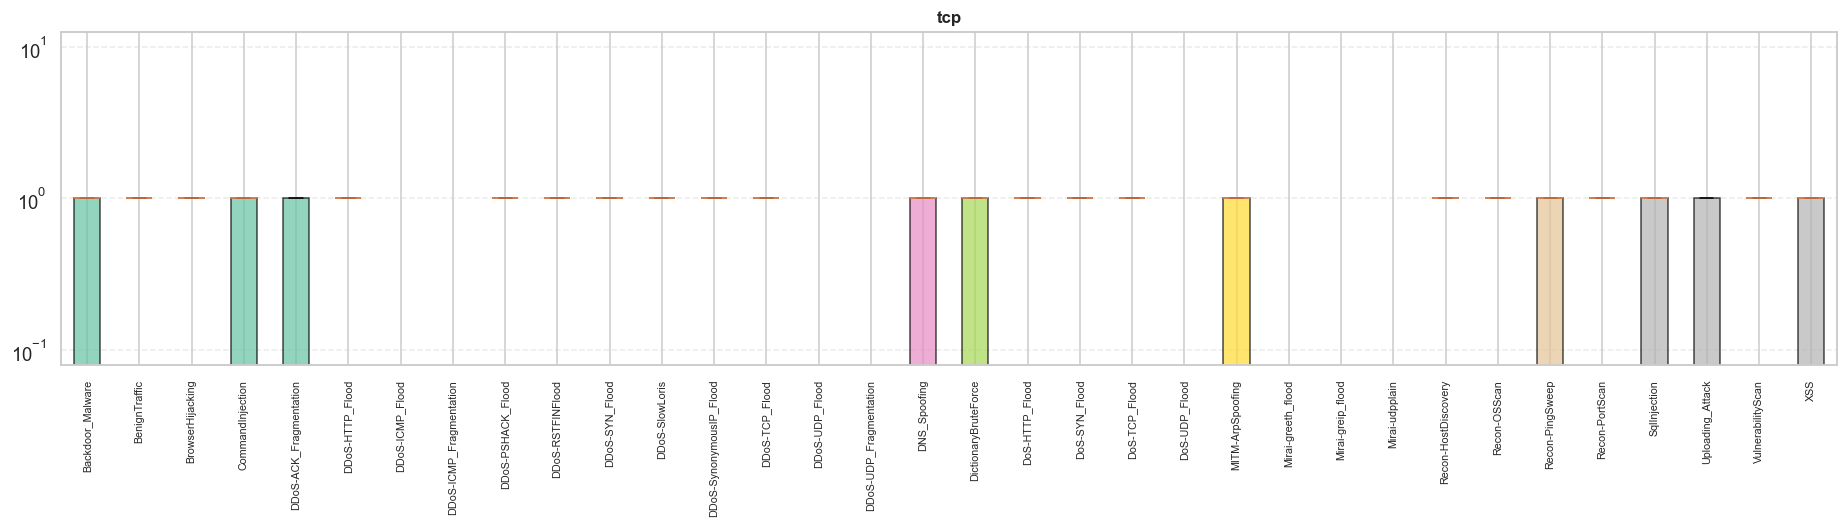

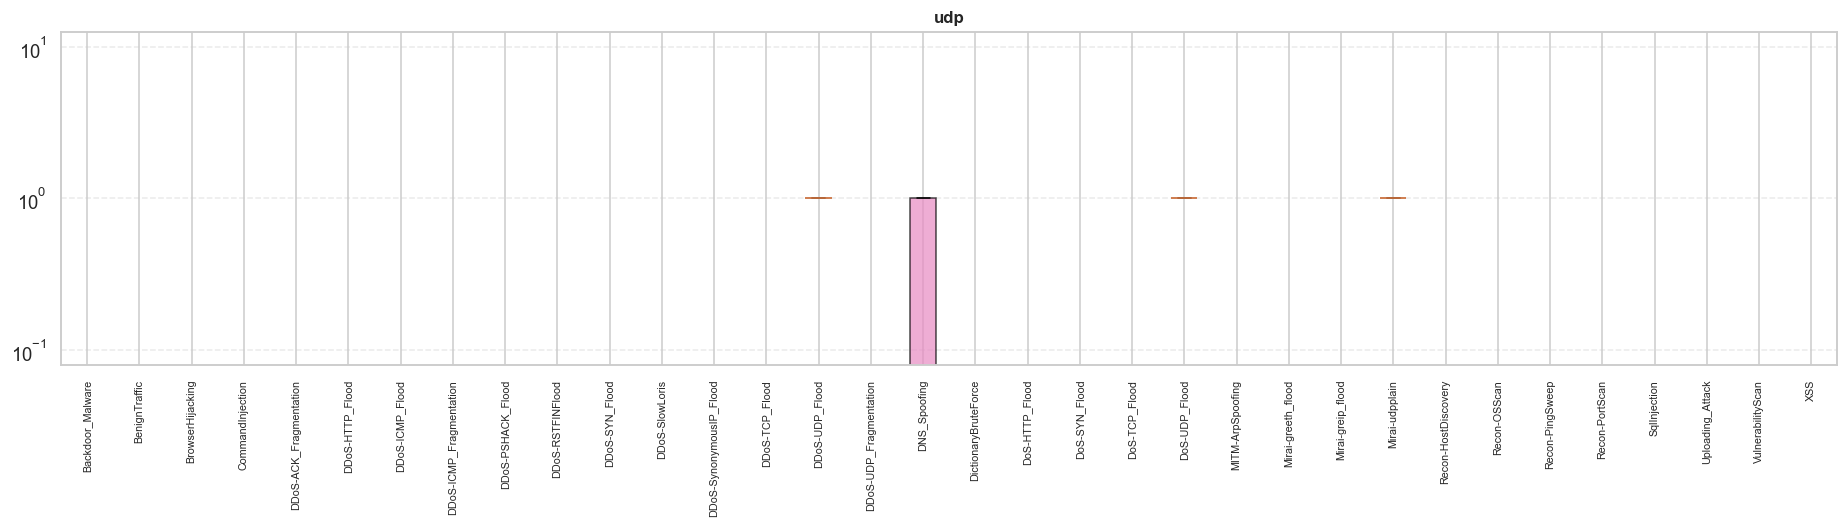

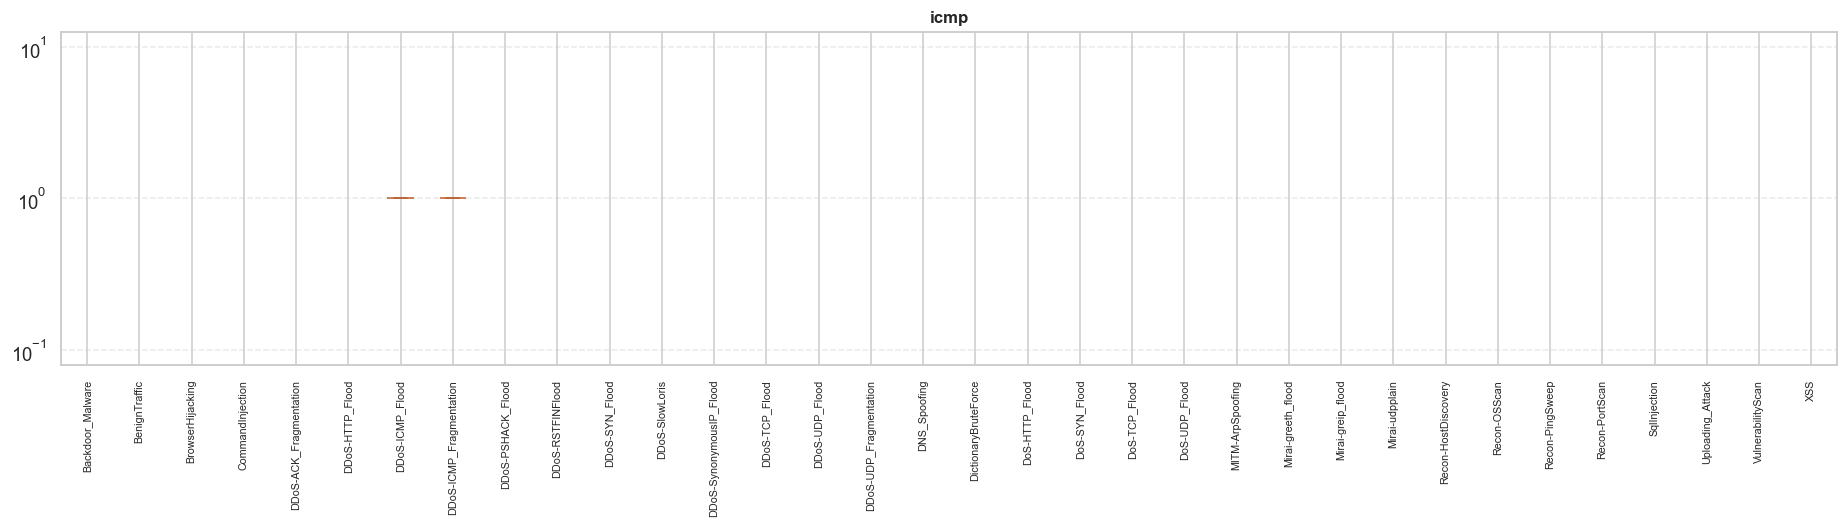

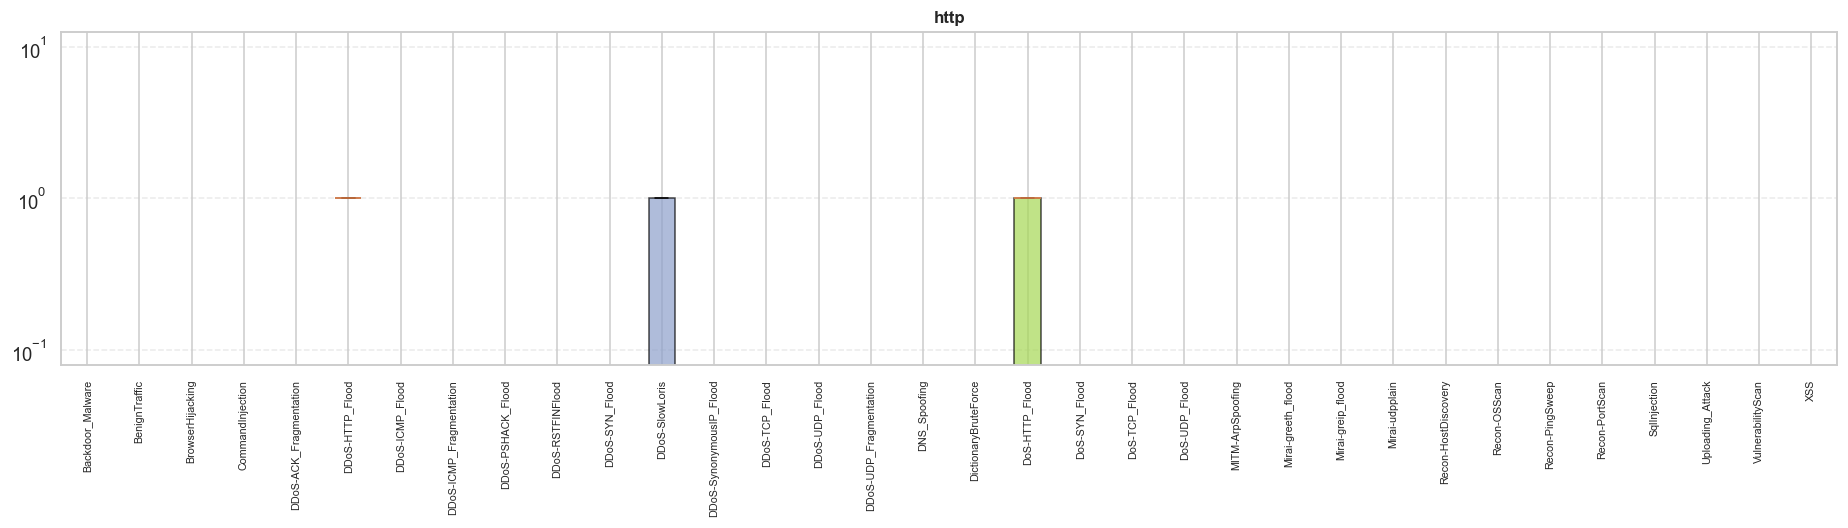

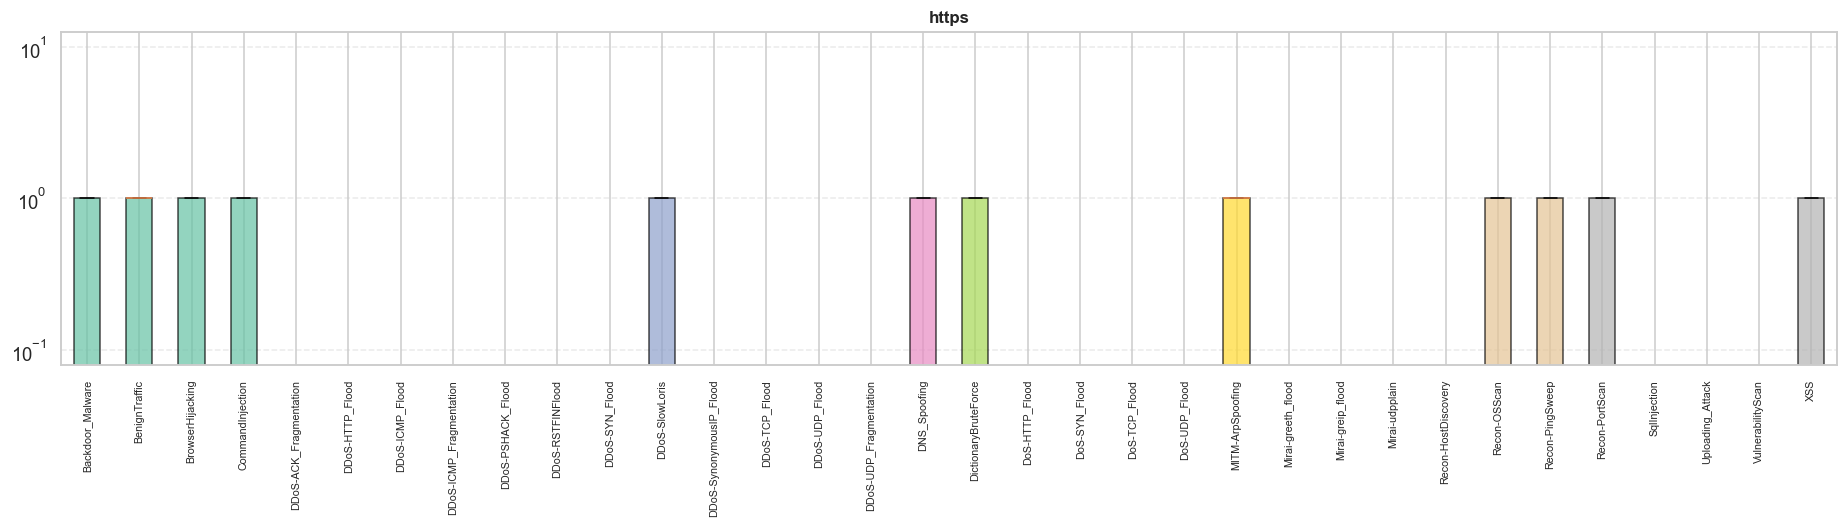

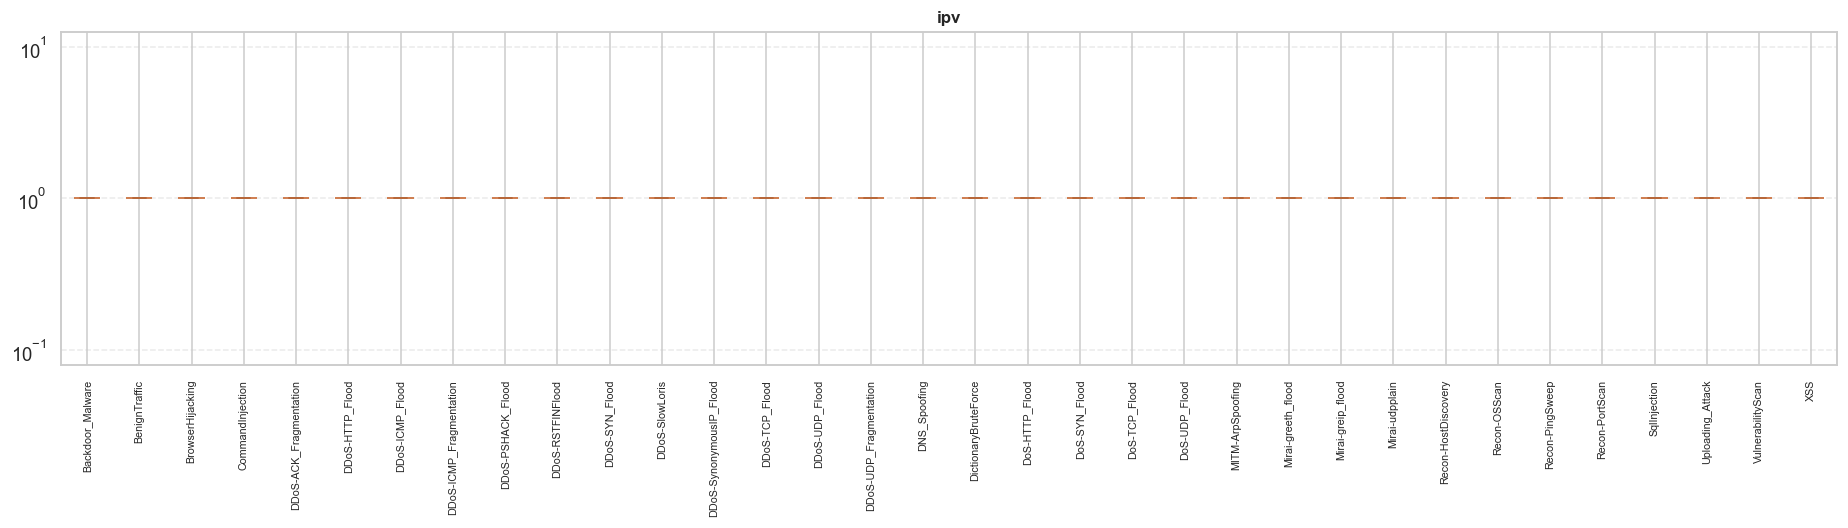

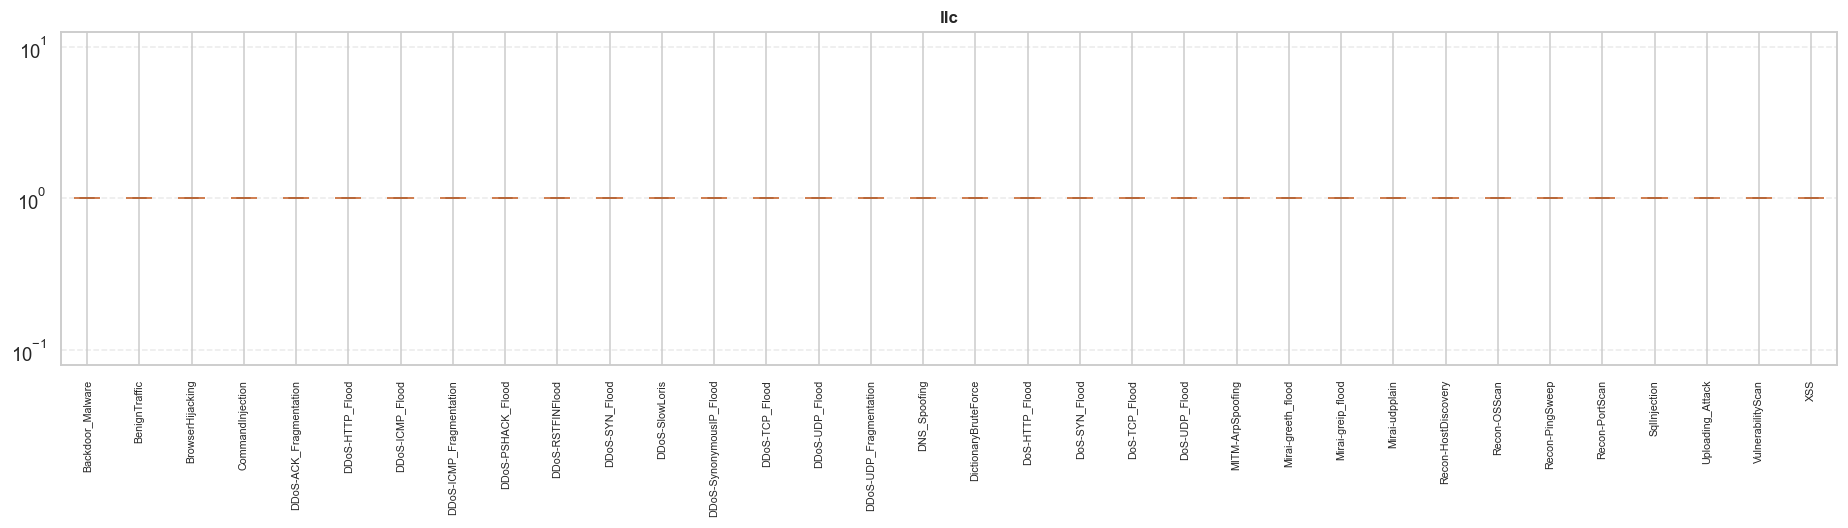

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización: boxplots de features candidatas por clase
#
# Estrategia para 45M filas en 16 GB de RAM:
#
#   1. UN ÚNICO groupby sobre todo el DataFrame calcula los percentiles
#      de todas las features candidatas a la vez. Un groupby es una
#      operación columnar de Pandas: no replica el DataFrame en memoria.
#
#   2. Se grafica UNA feature por vez: cada figura se crea, se renderiza
#      y se destruye con plt.close() antes de pasar a la siguiente.
#      Matplotlib nunca tiene más de un subplot en memoria simultáneamente.
#
# El objeto más grande en RAM durante el ploteo es all_stats:
# n_clases × n_features × 5 percentiles ≈ 34 × 28 × 5 floats = ~38 KB.
# ─────────────────────────────────────────────────────────────────────────────

# ── Paso 1: calcular todos los percentiles en un único groupby ───────────────
#
# Se calcula [Q1, mediana, Q3] para todas las features candidatas a la vez.
# Hacerlo en un solo groupby es ~28x más rápido que un groupby por feature
# dentro de un loop, y no aumenta el consumo de memoria.
print("Calculando percentiles por clase (único groupby)...")

# Reemplazar infinitos antes de agrupar para no contaminar los percentiles
cols_to_group: list[str] = [c for c in available_candidates if c in df.columns]
df_clean: pd.DataFrame = (
    df[cols_to_group + [LABEL_COL]]
    .replace([np.inf, -np.inf], np.nan)
)

# Un único groupby para todos los percentiles necesarios
# Resultado: MultiIndex (clase, quantile) × features
pct_all: pd.DataFrame = (
    df_clean
    .groupby(LABEL_COL)[cols_to_group]
    .quantile([0.25, 0.50, 0.75])
)

# También necesitamos min y max para los bigotes (acotados por 1.5×IQR)
minmax_all: pd.DataFrame = (
    df_clean
    .groupby(LABEL_COL)[cols_to_group]
    .agg(["min", "max"])
)

# Liberar el DataFrame limpio — ya no se necesita
del df_clean
gc.collect()

print(f"✓ Percentiles calculados para {len(cols_to_group)} features × {pct_all.index.get_level_values(0).nunique()} clases.")


# ── Paso 2: construir los stats por feature (formato ax.bxp) ─────────────────

def build_bxp_stats(
    feature: str,
    pct_df: pd.DataFrame,
    minmax_df: pd.DataFrame,
) -> list[dict]:
    """
    Construye la lista de dicts para ax.bxp() a partir de los percentiles
    precalculados por el groupby global.

    No accede al DataFrame original — opera solo sobre las tablas de
    estadísticas de ~38 KB ya calculadas.

    Args:
        feature:    Nombre de la feature a graficar.
        pct_df:     DataFrame de percentiles (MultiIndex clase × quantile).
        minmax_df:  DataFrame de min/max con MultiIndex de columnas.

    Returns:
        Lista de dicts con keys: label, med, q1, q3, whislo, whishi, fliers.
    """
    stats: list[dict] = []
    class_names = pct_df.index.get_level_values(0).unique()

    for cls in sorted(class_names):
        try:
            q1  = pct_df.loc[(cls, 0.25), feature]
            med = pct_df.loc[(cls, 0.50), feature]
            q3  = pct_df.loc[(cls, 0.75), feature]
        except KeyError:
            continue

        if pd.isna(q1) or pd.isna(med) or pd.isna(q3):
            continue

        iqr = q3 - q1
        raw_min = minmax_df.loc[cls, (feature, "min")]
        raw_max = minmax_df.loc[cls, (feature, "max")]

        stats.append({
            "label":  str(cls),
            "med":    float(med),
            "q1":     float(q1),
            "q3":     float(q3),
            "whislo": float(max(raw_min, q1 - 1.5 * iqr)),
            "whishi": float(min(raw_max, q3 + 1.5 * iqr)),
            "fliers": [],
        })

    return stats


# ── Paso 3: graficar una feature por vez ─────────────────────────────────────
#
# Cada figura se crea, se muestra y se destruye antes de la siguiente.
# plt.close() libera el canvas de Matplotlib de memoria inmediatamente.
# Nunca hay más de una figura activa simultáneamente.

class_names_sorted: list[str] = sorted(df[LABEL_COL].unique())
color_map: dict = dict(zip(
    class_names_sorted,
    plt.cm.Set2(np.linspace(0, 1, len(class_names_sorted)))
))

for feature in tqdm(cols_to_group, desc="Graficando features"):

    box_stats = build_bxp_stats(feature, pct_all, minmax_all)

    if not box_stats:
        continue

    # Figura individual: una sola feature, una sola figura en memoria
    fig, ax = plt.subplots(figsize=(max(10, len(box_stats) * 0.5), 5))

    bp = ax.bxp(
        box_stats,
        vert=True,
        showfliers=False,
        patch_artist=True,
    )
    for patch, stat in zip(bp["boxes"], box_stats):
        patch.set_facecolor(color_map.get(stat["label"], "#cccccc"))
        patch.set_alpha(0.7)

    medians = [s["med"] for s in box_stats if s["med"] > 0]
    if medians and min(medians) > 0:
        ax.set_yscale("log")

    ax.set_title(feature, fontweight="bold", fontsize=11)
    ax.set_xticks(range(1, len(box_stats) + 1))
    ax.set_xticklabels([s["label"] for s in box_stats], rotation=90, fontsize=7)
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    # Destruir la figura antes de crear la siguiente — libera el canvas
    plt.close(fig)
    del fig, ax, bp, box_stats


## 9. Limpieza — eliminar archivo temporal

Ejecutar esta celda al finalizar el análisis para eliminar el archivo
Feather temporal del disco. Este archivo fue creado exclusivamente como
buffer de carga y no forma parte de los artefactos del proyecto.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Limpieza final
#
# 1. Eliminar el DataFrame del análisis de la RAM.
# 2. Eliminar el archivo Feather temporal del disco.
#
# Ejecutar esta celda siempre al cerrar el notebook.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Liberar RAM
del df
gc.collect()
print("✓ DataFrame eliminado de RAM.")

# 2. Eliminar archivo Feather temporal
if FEATHER_TEMP_PATH.exists():
    size_mb: float = FEATHER_TEMP_PATH.stat().st_size / 1024**2
    FEATHER_TEMP_PATH.unlink()
    print(f"✓ Archivo temporal eliminado: {FEATHER_TEMP_PATH} ({size_mb:.1f} MB liberados).")
else:
    print(f"  El archivo {FEATHER_TEMP_PATH} no existe. Nada que eliminar.")

### 9.1 Estructura del dataset

- **Total de filas cargadas:** *46,686,579*
- **Total de columnas:** *47*
- **Tipos de dato predominante:** float64
- **Columnas categóricas detectadas:** Columnas de tipo object : 1  → ['label']


### 9.2 Desbalance de clases

- **Imbalance Ratio (IR):** *Desbalance severo (IR > 100). Se requerirá SMOTE o clase ponderada*
- **Clase mayoritaria:** *'DDoS-ICMP_Flood'  (7,200,504 muestras)*
- **Clase minoritaria:** *'Uploading_Attack'  (1,252 muestras)*
- **Estrategia recomendada:** *(SMOTE / undersampling / class_weight — completar según IR)*

### 9.3 Calidad de datos

- **Valores NaN encontrados:** *Ninguno*
- **Valores infinitos encontrados:** *Ninguno*
- **Features con >85% de ceros:**                  
feature          zero_pct        
telnet           100.0000
smtp             100.0000
irc              100.0000
cwr_flag_number   99.9999
ece_flag_number   99.9999
dhcp              99.9998
ssh               99.9959
drate             99.9937
arp               99.9934
dns               99.9869
http              95.1766
https             94.4901
fin_flag_number   91.3428
psh_flag_number   91.2250
rst_flag_number   90.9495
ack_flag_number   87.6568
ack_count         87.6148
fin_count         86.7308

- **Features con outliers extremos (>5%):** 

Top 15 features con mayor proporción de outliers:
                 outlier_count  outlier_pct
duration              12388948      26.5364
header_length         11146138      23.8744
syn_count             11004085      23.5701
udp                    9893707      21.1918
rate                   9886428      21.1762
srate                  9886428      21.1762
covariance             9867900      21.1365
syn_flag_number        9679775      20.7335
rst_count              9616255      20.5975
urg_count              9544726      20.4443
radius                 8382211      17.9542
std                    8318512      17.8178
max                    8202730      17.5698
flow_duration          7915386      16.9543
icmp                   7643600      16.3722


### 9.4 Correlación

- **Pares con |r| ≥ 0.95:** 

Top pares altamente correlacionados:
      feature_a       feature_b  pearson_r
           rate           srate     1.0000
            ipv             llc     1.0000
            std          radius     1.0000
         number          weight     0.9996
            iat          weight     0.9973
            iat          number     0.9960
fin_flag_number       ack_count     0.9859
fin_flag_number rst_flag_number     0.9756
            avg        magnitue     0.9684
rst_flag_number       ack_count     0.9620
            max             std     0.9526
            max          radius     0.9526
            avg        tot_size     0.9410
        tot_sum             avg     0.9342
       tot_size        magnitue     0.9292
        tot_sum        magnitue     0.9226


### 9.5 Poder discriminativo de features candidatas

- **Features con alta separación entre clases:** *(completar tras boxplots)*
- **Features poco discriminativas:** *(completar)*

### 9.6 Decisiones para Hito 2

| Decisión | Motivo |
|---|---|
| *(completar)* | *(completar)* |